In [1]:
import pickle as pkl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import arviz as az
import scipy.stats as stats

# python font no dingbattes
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
#Change the working directory
import os
os.chdir('/home/apoorva/Desktop/MZB-new-analysis')

In [3]:
#open the output file

import os
import sys
import numpy as _np

file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T1.pkl'
with open(file_path, 'rb') as f:
    try:
        data_neutral_T1 = pkl.load(f)
    except ModuleNotFoundError:
        # provide a fallback module mapping for numpy._core if missing (fixes some pickle import paths)
        if 'numpy._core' not in sys.modules:
            sys.modules['numpy._core'] = sys.modules.get('numpy.core', _np)
        f.seek(0)
        data_neutral_T1 = pkl.load(f)

file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T2.pkl'
with open(file_path, 'rb') as f:
    data_neutral_T2 = pkl.load(f)

file_path = 'data/New output (pkl)/Steady State/SHM/SHM_FO.pkl'
with open(file_path, 'rb') as f:
    data_neutral_FO = pkl.load(f)
    
# file_path = 'data/New output (pkl)/Steady State/SHM/SHM_T2MZP.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral_T2MZP = pkl.load(f)
    
# file_path = '/home/apoorva/Desktop/work/MZ_analysis/data/New output (pkl)/Steady State/No_transformation/SHM_T2MZP_notransform.pkl'
# with open(file_path, 'rb') as f:
#     data_neutral_T2MZP = pkl.load(f)
    



/home/apoorva/Desktop/MZB-new-analysis/.venv-1/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ModuleNotFoundError: No module named 'numpy._core'

In [ ]:
# open experimental data file 
df = pd.read_csv('/home/apoorva/Desktop/MZB-new-analysis/data/new_data_MZB.csv')
df = df.sort_values(by='Age at S1K')
df.loc[1, 'Age at BMT'] = 74
print(df)


                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          74          88   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [ ]:
#Add one column in df_Ki67 and df_Nfd for grouping the data based on age at bmt

df['agebin'] = pd.cut(df['Age at BMT'], bins=[0,70, 140], labels=['<10 weeks', '>10 weeks'])
print(df)

                                    Unnamed: 0  Age at BMT  Age at S1K  \
3           20181204_2-5wks_SPLEEN_002_019.fcs          41          59   
5             20181207_3wks_SPLEEN_002_049.fcs          41          62   
7             20181213_4wks_SPLEEN_002_025.fcs          41          69   
9        20181220_5wks_SPLEEN_CD1d_002_066.fcs          41          76   
1       20181129_Bcells_SPLEEN_14d_002_020.fcs          74          88   
0       20181129_Bcells_SPLEEN_14d_001_019.fcs          74          88   
2           20181204_2-5wks_SPLEEN_001_018.fcs          74          92   
4             20181207_3wks_SPLEEN_001_048.fcs          74          95   
6             20181213_4wks_SPLEEN_001_024.fcs          74         102   
8        20181220_5wks_SPLEEN_CD1d_001_065.fcs          74         109   
10             20190312_SPLEEN_54d_004_020.fcs          41         119   
11  20190205_MV61_BuChi_12w_Spleen_001_028.fcs          41         123   
12  20190205_MV61_BuChi_12w_Spleen_002

In [ ]:
# my_pal = ['#FAA51A','#984763','#2e2976']
my_pal = ["#f99f1b", "#282a73"]


In [ ]:
data_neutral_T1.host_ki_pred2.shape

(5000, 662)

In [ ]:
#Filter predicted values 
MZ_predT1 = data_neutral_T1.MZ_counts_pred1[:, 7:]
Nfd_predT1 = data_neutral_T1.Nfd_pred1[:, 7:]
ki_host_predT1 = data_neutral_T1.host_ki_pred1[:, 7:]
ki_donor_predT1 = data_neutral_T1.donor_ki_pred1[:, 7:]

MZ_predT2 = data_neutral_T2.MZ_counts_pred1[:, 7:]
Nfd_predT2 = data_neutral_T2.Nfd_pred1[:, 7:]
ki_host_predT2 = data_neutral_T2.host_ki_pred1[:, 7:]
ki_donor_predT2 = data_neutral_T2.donor_ki_pred1[:, 7:]

MZ_predFO = data_neutral_FO.MZ_counts_pred1[:, 7:]
Nfd_predFO = data_neutral_FO.Nfd_pred1[:, 7:]
ki_host_predFO = data_neutral_FO.host_ki_pred1[:, 7:]
ki_donor_predFO = data_neutral_FO.donor_ki_pred1[:, 7:]

MZ_predT2MZP = data_neutral_T2MZP.MZ_counts_pred1[:, 7:]
Nfd_predT2MZP = data_neutral_T2MZP.Nfd_pred1[:, 7:]
ki_host_predT2MZP = data_neutral_T2MZP.host_ki_pred1[:, 7:]
ki_donor_predT2MZP = data_neutral_T2MZP.donor_ki_pred1[:, 7:]


NameError: name 'data_neutral_FO' is not defined

In [ ]:
# MZ_errorT1 = data_neutral_T1.MZ_counts_pred1_err[:, 7:]
MZ_errorT2 = data_neutral_T2.MZ_counts_pred1_err[:, 7:]
MZ_errorFO = data_neutral_FO.MZ_counts_pred1_err[:, 7:]


# Separate age at s1k for two bins
hostage_bin1 = df[df['agebin'] == '<10 weeks']['Age at S1K'].values
hostage_bin2 = df[df['agebin'] == '>10 weeks']['Age at S1K'].values

#Plot Mz counts for three precursors
ts1= np.arange(59, 750, 1)
ts2= np.arange(88, 750, 1)

age_indices_bin1 = []
age_indices_bin2 = []
# timepoints_agebin1 = []
# timepoints_agebin2 = []
for age in hostage_bin1:
    idx_arr = np.where(ts1 == age)[0]
    age_indices_bin1.append(idx_arr[0])

for age in hostage_bin2:
    idx_arr = np.where(ts2 == age)[0]
    age_indices_bin2.append(idx_arr[0])


# Mz_error_T1 = MZ_errorT1[:, age_indices_bin1]
Mz_error_T2 = MZ_errorT2[:, age_indices_bin1]
Mz_error_FO = MZ_errorFO[:, age_indices_bin1]


# Mz_error2_T1 = data_neutral_T1.MZ_counts_pred2_err[:, age_indices_bin2]
Mz_error2_T2 = data_neutral_T2.MZ_counts_pred2_err[:, age_indices_bin2]
Mz_error2_FO = data_neutral_FO.MZ_counts_pred2_err[:, age_indices_bin2]

print(age_indices_bin1)
# print(Mz_error_T1.shape)
print(Mz_error_T2.shape)


def plot_credible_intervals(x, data, color, capsize=2, alpha=0.025):
    """Plot error bars with quantile-based credible intervals"""
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, alpha, axis=0)
    upper_ci = np.quantile(data, 1-alpha, axis=0)
    
    plt.errorbar(x, mean_data, 
                yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                color=color, capsize=capsize, elinewidth=1)
    
    return mean_data, lower_ci, upper_ci

# Usage:
# plot_credible_intervals(ts1, Mz_error_T1, my_pal[0])
# plot_credible_intervals(ts2, Mz_error_T2, my_pal[1])
# plot_credible_intervals(ts2, Mz_error_FO, my_pal[2])



#time points


[np.int64(0), np.int64(3), np.int64(10), np.int64(17), np.int64(60), np.int64(64), np.int64(65), np.int64(82), np.int64(99), np.int64(153), np.int64(160)]
(5000, 11)


/var/folders/ps/wzpv12c53fsgbwcd_wt33b5r0000gn/T/ipykernel_14052/2713980683.py:33: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 800)


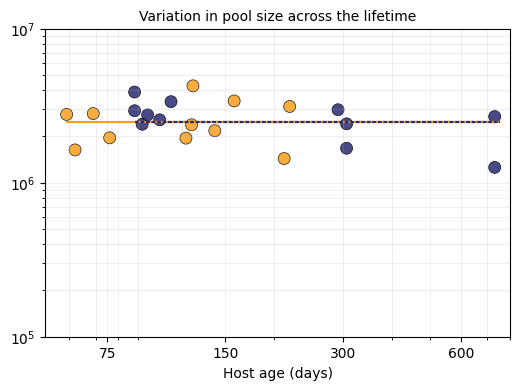

In [ ]:
#Plot Mz counts for three precursors
ts1= np.arange(59, 750, 1)
ts2= np.arange(88, 750, 1)

plt.figure(figsize=(6, 4))

sns.scatterplot(data=df, x='Age at S1K', y='total_MZ', alpha=0.85, hue='agebin', edgecolor='black', s=75, linewidth=0.5, legend=False, palette=my_pal)
plt.plot(ts1, np.mean(MZ_predT1, axis=0), color=my_pal[0], linestyle='dashed')
plt.plot(ts2, np.mean(data_neutral_T1.MZ_counts_pred2, axis=0), color=my_pal[1], linestyle='dashed')
# plt.fill_between(ts1, np.quantile(MZ_predT1, 0.025, axis=0), np.quantile(MZ_predT1, 0.975, axis=0), alpha=0.05, color=my_pal[0])
# plt.fill_between(ts2, np.quantile(data_neutral_T1.MZ_counts_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.MZ_counts_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])

# # Plot error bars
# plot_credible_intervals(hostage_bin1, Mz_error_T1, my_pal[0])
# plot_credible_intervals(hostage_bin2, Mz_error2_T1, my_pal[1])


plt.plot(ts1, np.mean(MZ_predT2, axis=0), color=my_pal[0])
plt.plot(ts2, np.mean(data_neutral_T2.MZ_counts_pred2, axis=0), color=my_pal[1])
# plt.fill_between(ts1, np.quantile(MZ_predT2, 0.025, axis=0), np.quantile(MZ_predT2, 0.975, axis=0), alpha=0.05, color=my_pal[0])
# plt.fill_between(ts2, np.quantile(data_neutral_T2.MZ_counts_pred2, 0.025, axis=0), np.quantile(data_neutral_T2.MZ_counts_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])

plt.plot(ts1, np.mean(MZ_predT2MZP, axis=0), color=my_pal[0], linestyle='dotted')
plt.plot(ts2, np.mean(data_neutral_FO.MZ_counts_pred2, axis=0), color=my_pal[1], linestyle='dotted')
# plt.fill_between(ts1, np.quantile(MZ_predFO, 0.025, axis=0), np.quantile(MZ_predFO, 0.975, axis=0), alpha=0.05, color=my_pal[0])
# plt.fill_between(ts2, np.quantile(data_neutral_FO.MZ_counts_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.MZ_counts_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])



plt.yscale('log')  # sets the y-axis to a logarithmic scale
plt.ylim(1e5, 1e7)
plt.xscale('log')
plt.xlim(0, 800)
plt.xticks([75, 150, 300, 600], [75, 150, 300, 600])
plt.ylabel('')
plt.tick_params(axis='both', labelsize=10)
plt.xlabel('Host age (days)', fontsize=10)
plt.title('Variation in pool size across the lifetime', fontsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
# plt.tight_layout()
#Save the figure
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Chimera_Counts.pdf', dpi=300, bbox_inches='tight')
plt.show()    



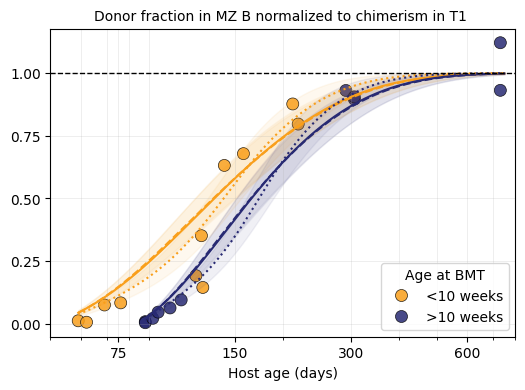

In [ ]:
#PLOT Nfd


plt.figure(figsize=(6, 4))

sns.scatterplot(data=df, x='Age at S1K', y='Nfd_MZ', hue='agebin', edgecolor='black', linewidth=0.5, alpha=0.85, s=75, legend= True, palette=my_pal)
plt.plot(ts1, np.mean(Nfd_predT1, axis=0), color=my_pal[0], linestyle='dashed')
plt.plot(ts2, np.mean(data_neutral_T1.Nfd_pred2, axis=0), color=my_pal[1], linestyle='dashed')
plt.fill_between(ts1, np.quantile(Nfd_predT1, 0.025, axis=0), np.quantile(Nfd_predT1, 0.975, axis=0), alpha=0.065, color=my_pal[0])
plt.fill_between(ts2, np.quantile(data_neutral_T1.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.Nfd_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])

plt.plot(ts1, np.mean(Nfd_predT2, axis=0), color=my_pal[0])
plt.plot(ts2, np.mean(data_neutral_T2.Nfd_pred2, axis=0), color=my_pal[1])
plt.fill_between(ts1, np.quantile(Nfd_predT2, 0.025, axis=0), np.quantile(Nfd_predT2, 0.975, axis=0), alpha=0.065, color=my_pal[0])
plt.fill_between(ts2, np.quantile(data_neutral_T2.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral_T2.Nfd_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])

plt.plot(ts1, np.mean(Nfd_predFO, axis=0), color=my_pal[0], linestyle ='dotted')
plt.plot(ts2, np.mean(data_neutral_FO.Nfd_pred2, axis=0), color=my_pal[1], linestyle='dotted')
plt.fill_between(ts1, np.quantile(Nfd_predFO, 0.025, axis=0), np.quantile(Nfd_predFO, 0.975, axis=0), alpha=0.065, color=my_pal[0])
plt.fill_between(ts2, np.quantile(data_neutral_FO.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.Nfd_pred2, 0.975, axis=0), alpha=0.065, color=my_pal[1])


plt.xlim(50, 800)
plt.xscale('log')
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
plt.xlabel('Host age (days)', fontsize=10)
plt.title('Donor fraction in MZ B normalized to chimerism in T1 ', fontsize=10)
plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1)
plt.tick_params(axis='both', labelsize=10)
plt.legend(title='Age at BMT', fontsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Chimera_Nfd.pdf', dpi=300)
plt.show() 


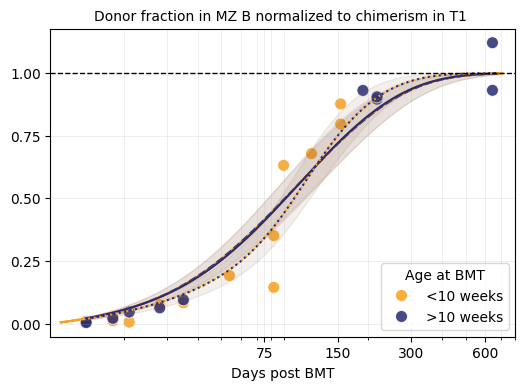

In [ ]:
#PLOT Nfd against days post Bmt 
tb1 = np.arange(52, 750,1) - 41
tb2 = np.arange(88, 750,1) - 74


plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x='Days postBMT', y='Nfd_MZ', hue='agebin', alpha=0.85, s=75, legend= True, palette=my_pal)
# plt.plot(tb1, np.mean(Nfd_predT1, axis=0), color=my_pal[0], linestyle='dashed')
plt.plot(tb1, np.mean(data_neutral_T1.Nfd_pred1, axis=0), color=my_pal[0], linestyle='dashed')
plt.plot(tb2, np.mean(data_neutral_T1.Nfd_pred2, axis=0), color=my_pal[1], linestyle='dashed')

# plt.fill_between(tb1, np.quantile(Nfd_predT1, 0.025, axis=0), np.quantile(Nfd_predT1, 0.975, axis=0), alpha=0.05, color=my_pal[0])
plt.fill_between(tb1, np.quantile(data_neutral_T1.Nfd_pred1, 0.025, axis=0), np.quantile(data_neutral_T1.Nfd_pred1, 0.975, axis=0), alpha=0.05, color=my_pal[0])
plt.fill_between(tb2, np.quantile(data_neutral_T1.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.Nfd_pred2, 0.975, axis=0), alpha=0.05, color=my_pal[1])



# plt.plot(tb1, np.mean(Nfd_predT2, axis=0), color=my_pal[0])
plt.plot(tb1, np.mean(data_neutral_T2.Nfd_pred1, axis=0), color=my_pal[0])
plt.plot(tb2, np.mean(data_neutral_T2.Nfd_pred2, axis=0), color=my_pal[1])

# plt.fill_between(tb2, np.quantile(Nfd_predT2, 0.025, axis=0), np.quantile(Nfd_predT2, 0.975, axis=0), alpha=0.05, color=my_pal[0])
plt.fill_between(tb1, np.quantile(data_neutral_T2.Nfd_pred1, 0.025, axis=0), np.quantile(data_neutral_T2.Nfd_pred1, 0.975, axis=0), alpha=0.05, color=my_pal[0])
plt.fill_between(tb2, np.quantile(data_neutral_T2.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral_T2.Nfd_pred2, 0.975, axis=0), alpha=0.05, color=my_pal[1])


# plt.plot(tb1, np.mean(Nfd_predFO, axis=0), color=my_pal[0], linestyle ='dotted')
plt.plot(tb1, np.mean(data_neutral_FO.Nfd_pred1, axis=0), color=my_pal[0], linestyle='dotted')
plt.plot(tb2, np.mean(data_neutral_FO.Nfd_pred2, axis=0), color=my_pal[1], linestyle='dotted')

# plt.fill_between(tb1, np.quantile(Nfd_predFO, 0.025, axis=0), np.quantile(Nfd_predFO, 0.975, axis=0), alpha=0.05, color=my_pal[0])
plt.fill_between(tb1, np.quantile(data_neutral_FO.Nfd_pred1, 0.025, axis=0), np.quantile(data_neutral_FO.Nfd_pred1, 0.975, axis=0), alpha=0.05, color=my_pal[0])
plt.fill_between(tb2, np.quantile(data_neutral_FO.Nfd_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.Nfd_pred2, 0.975, axis=0), alpha=0.05, color=my_pal[1])



plt.xlim(10, 800)
plt.xscale('log')
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
plt.xlabel('Days post BMT', fontsize=10)
plt.title('Donor fraction in MZ B normalized to chimerism in T1 ', fontsize=10)
plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1)
plt.tick_params(axis='both', labelsize=10)
plt.legend(title='Age at BMT', fontsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Chimera_Nfd_dayspostBmt.pdf', dpi=300)
plt.show() 

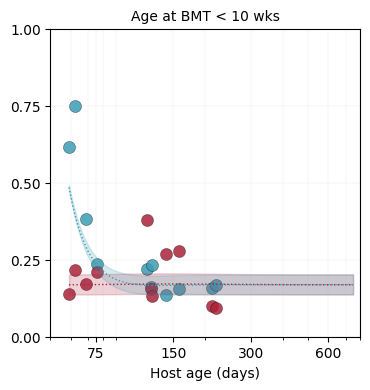

In [ ]:

#Construct a new dataframe for agebin1, agebin2 
df_Ki67_bin1 = df[df['agebin'] == '<10 weeks']
df_Ki67_bin2 = df[df['agebin'] == '>10 weeks']


plt.figure(figsize=(4, 4))
sns.scatterplot(data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#3b9bb3')
sns.scatterplot(data=df_Ki67_bin1, x='Age at S1K', y='frac_Ki67+_MZ_host',edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#ab2239')


# plt.plot(ts1, np.mean(ki_host_predT1 , axis=0), color='#ab2239', linestyle='dashed', linewidth=1)
# plt.fill_between(ts1, np.quantile(ki_host_predT1 , 0.025, axis=0), np.quantile(ki_host_predT1 , 0.975, axis=0), color='#ab2239', alpha=0.2)
# plt.plot(ts1, np.mean(ki_donor_predT1, axis=0), color='#3b9bb3', linestyle='dashed', linewidth=1)
# plt.fill_between(ts1, np.quantile(ki_donor_predT1, 0.025, axis=0), np.quantile(ki_donor_predT1, 0.975, axis=0), color='#3b9bb3', alpha=0.2)


# plt.plot(ts1, np.mean(ki_host_predT2 , axis=0), color='#ab2239', linewidth=1)
# plt.fill_between(ts1, np.quantile(ki_host_predT2 , 0.025, axis=0), np.quantile(ki_host_predT2 , 0.975, axis=0), color='#ab2239', alpha=0.2)
# plt.plot(ts1, np.mean(ki_donor_predT2, axis=0), color='#3b9bb3', linewidth=1)
# plt.fill_between(ts1, np.quantile(ki_donor_predT2, 0.025, axis=0), np.quantile(ki_donor_predT2, 0.975, axis=0), color='#3b9bb3', alpha=0.2)


plt.plot(ts1, np.mean(ki_host_predFO , axis=0), color='#ab2239', linestyle='dotted', linewidth=1)
plt.fill_between(ts1, np.quantile(ki_host_predFO , 0.025, axis=0), np.quantile(ki_host_predFO , 0.975, axis=0), color='#ab2239', alpha=0.2)
plt.plot(ts1, np.mean(ki_donor_predFO, axis=0), color= '#3b9bb3', linestyle='dotted', linewidth=1)
plt.fill_between(ts1, np.quantile(ki_donor_predFO, 0.025, axis=0), np.quantile(ki_donor_predFO, 0.975, axis=0), color= '#3b9bb3', alpha=0.2)


plt.xlim(50, 800)
plt.ylim(0, 1)
plt.xscale('log')
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
# plt.ylabel('Proportion of Ki67+ MZ cells', fontsize=10)
plt.title('Age at BMT < 10 wks', fontsize=10)
plt.xlabel('Host age (days)', fontsize=10)
# plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1)
plt.tick_params(axis='both', labelsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.25, alpha=0.3)  
# plt.legend(labels=['Donor', 'Host'])
# plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Chimera_Ki67Bin1_FO.pdf', dpi=300)
plt.show() 

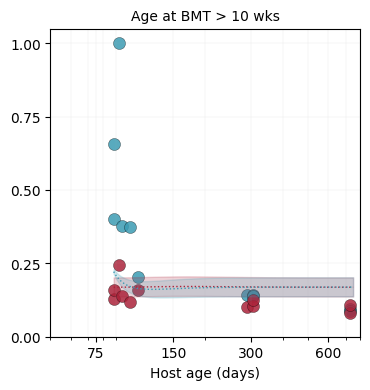

In [ ]:

plt.figure(figsize=(4, 4))
sns.scatterplot(data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#3b9bb3')
sns.scatterplot(data=df_Ki67_bin2, x='Age at S1K', y='frac_Ki67+_MZ_host', edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#ab2239')

# plt.plot(ts2, np.mean(data_neutral_T1.host_ki_pred2, axis=0), color='#ab2239', linestyle='dashed', linewidth=1)
# plt.fill_between(ts2, np.quantile(data_neutral_T1.host_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.host_ki_pred2, 0.975, axis=0), color= '#ab2239', alpha=0.2)
# plt.plot(ts2, np.mean(data_neutral_T1.donor_ki_pred2, axis=0), color = '#3b9bb3', linestyle='dashed', linewidth=1)
# plt.fill_between(ts2, np.quantile(data_neutral_T1.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.2)


# plt.plot(ts2, np.mean(data_neutral_T2.host_ki_pred2 , axis=0), color='#ab2239', linewidth=1)
# plt.fill_between(ts2, np.quantile(data_neutral_T2.host_ki_pred2 , 0.025, axis=0), np.quantile(data_neutral_T2.host_ki_pred2, 0.975, axis=0), color='#ab2239', alpha=0.2)
# plt.plot(ts2, np.mean(data_neutral_T2.donor_ki_pred2, axis=0), color='#3b9bb3', linewidth=1)
# plt.fill_between(ts2, np.quantile(data_neutral_T2.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_T2.donor_ki_pred2, 0.975, axis=0), color='#3b9bb3', alpha=0.2)


plt.plot(ts2, np.mean(data_neutral_FO.host_ki_pred2 , axis=0),  color = '#ab2239', linestyle='dotted', linewidth=1)
plt.fill_between(ts2, np.quantile(data_neutral_FO.host_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.host_ki_pred2 , 0.975, axis=0), color = '#ab2239', alpha=0.2)
plt.plot(ts2, np.mean(data_neutral_FO.donor_ki_pred2, axis=0),  color= '#3b9bb3', linestyle='dotted', linewidth=1)
plt.fill_between(ts2, np.quantile(data_neutral_FO.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.2)


plt.xlim(50, 800)
plt.ylim(0, 1.05)
plt.xscale('log')
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
# plt.ylabel('Proportion of Ki67+ MZ cells', fontsize=12)
plt.title('Age at BMT > 10 wks', fontsize=10)
plt.xlabel('Host age (days)', fontsize=10)
# plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1)
plt.tick_params(axis='both', labelsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.25, alpha=0.3)  
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Chimera_Ki67Bin2_FO.pdf', dpi=300)
plt.show() 

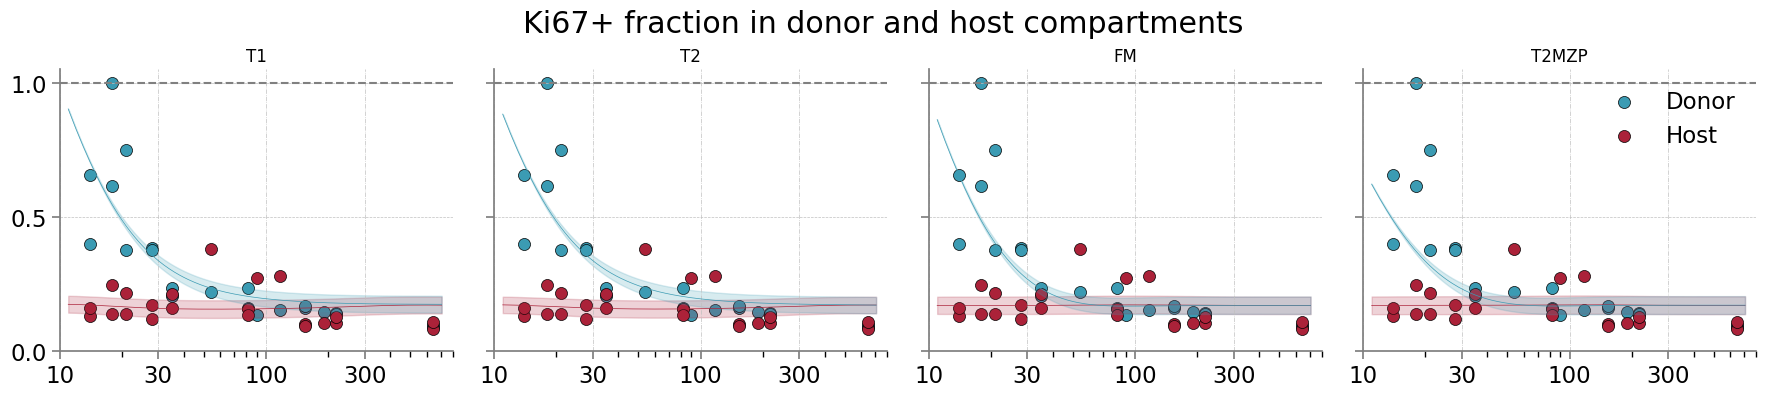

In [ ]:
#Construct a new dataframe for agebin1, agebin2 
df_Ki67_bin1 = df[df['agebin'] == '<10 weeks']
df_Ki67_bin2 = df[df['agebin'] == '>10 weeks']

sns.set_context("notebook", font_scale=1.5)

# Create figure with 3 subplots in one row
fig, axes = plt.subplots(1, 4, figsize=(18,4.5)) #5.5 and 4
# add super title
fig.suptitle('Ki67+ fraction in donor and host compartments', y=0.9)
# for ax in axes.flat:
#     title = ax.get_title()
#     subset_name = title.split('=')[1].strip()
#     axes.set_title(f'{subset_name}', fontsize=14)
# Data for each model
models = [
    {'data': data_neutral_T1, 'style': 'solid', 'title': 'T1'},
    {'data': data_neutral_T2, 'style': 'solid', 'title': 'T2'}, 
    {'data': data_neutral_FO, 'style': 'solid', 'title': 'FM'},
    {'data': data_neutral_T2MZP, 'style': 'solid', 'title': 'T2MZP'}
]

for i, model in enumerate(models):
    # Scatter plots (same for all)
    axes[i].scatter(df['Days postBMT'], df['frac_Ki67+_MZ_donor'], 
                   s=75,  color='#3b9bb3', edgecolor='black', linewidth=0.5, label='Donor')
    axes[i].scatter(df['Days postBMT'], df['frac_Ki67+_MZ_host'], 
                    s=75, color='#ab2239', edgecolor='black', linewidth=0.5, label='Host')

    # Model predictions
    axes[i].plot(tb1, np.mean(model['data'].host_ki_pred1, axis=0), 
                 color='#ab2239', linestyle=model['style'], linewidth=0.5)
    axes[i].fill_between(tb1, np.quantile(model['data'].host_ki_pred1, 0.025, axis=0), 
                         np.quantile(model['data'].host_ki_pred1, 0.975, axis=0), 
                         color='#ab2239', alpha=0.2)
    axes[i].plot(tb1, np.mean(model['data'].donor_ki_pred1, axis=0), 
                 color='#3b9bb3', linestyle=model['style'], linewidth=0.5)
    axes[i].fill_between(tb1, np.quantile(model['data'].donor_ki_pred1, 0.025, axis=0), 
                         np.quantile(model['data'].donor_ki_pred1, 0.975, axis=0), 
                         color='#3b9bb3', alpha=0.2)
    
    # Formatting (same for all)
    axes[i].set_title(model['title'], fontsize=12)
    axes[i].set_ylim(0, 1.05)
    axes[i].set_xlim(10, 800)
    axes[i].set_xscale('log')
    axes[i].set_xticks([10, 30, 100, 300],[10, 30, 100, 300])
    axes[i].grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
    axes[i].grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
    axes[i].axhline(1, ls='--', color='gray')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('gray')
    axes[i].spines['bottom'].set_color('gray')
    axes[i].tick_params(axis='both', color='gray', labelcolor='black')
    
    
    # Y-label only for first subplot
    if i == 0:
        axes[i].set_yticks([0.0, 0.5, 1], [0.0, 0.5,1.0])
        
    else:
        axes[i].set_yticks([0.0, 0.5, 1], [])
axes[3].legend(loc='upper right', frameon=False)
plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Ki67+fraction_all_models.pdf', dpi=300, bbox_inches='tight')
plt.show()

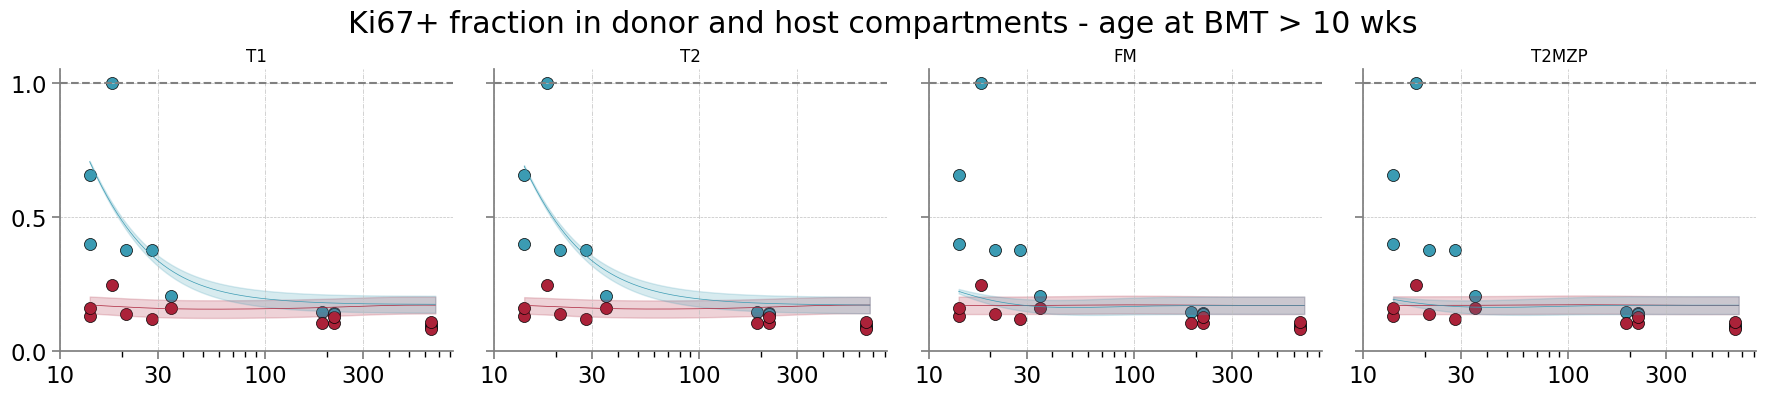

In [ ]:
#Construct a new dataframe for agebin1, agebin2 
df_Ki67_bin1 = df[df['agebin'] == '<10 weeks']
df_Ki67_bin2 = df[df['agebin'] == '>10 weeks']

# Create figure with 3 subplots in one row
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

fig.suptitle('Ki67+ fraction in donor and host compartments - age at BMT > 10 wks', y=0.9)
# Data for each model
models = [
    {'data': data_neutral_T1, 'style': 'solid', 'title': 'T1'},
    {'data': data_neutral_T2, 'style': 'solid', 'title': 'T2'}, 
    {'data': data_neutral_FO, 'style': 'solid', 'title': 'FM'},
    {'data': data_neutral_T2MZP, 'style': 'solid', 'title': 'T2MZP'}
]

for i, model in enumerate(models):
    # Scatter plots (same for all)
    axes[i].scatter(df_Ki67_bin2['Days postBMT'], df_Ki67_bin2['frac_Ki67+_MZ_donor'], 
                    s=75,  color='#3b9bb3', edgecolor='black', linewidth=0.5, label='Donor')
    axes[i].scatter(df_Ki67_bin2['Days postBMT'], df_Ki67_bin2['frac_Ki67+_MZ_host'], 
                    s=75, color='#ab2239', edgecolor='black', linewidth=0.5, label='Host')
    
    # Model predictions
    axes[i].plot(tb2, np.mean(model['data'].host_ki_pred2, axis=0), 
                 color='#ab2239', linestyle=model['style'], linewidth=0.5)
    axes[i].fill_between(tb2, np.quantile(model['data'].host_ki_pred2, 0.025, axis=0), 
                         np.quantile(model['data'].host_ki_pred2, 0.975, axis=0), 
                         color='#ab2239', alpha=0.2)
    axes[i].plot(tb2, np.mean(model['data'].donor_ki_pred2, axis=0), 
                 color='#3b9bb3', linestyle=model['style'], linewidth=0.5)
    axes[i].fill_between(tb2, np.quantile(model['data'].donor_ki_pred2, 0.025, axis=0), 
                         np.quantile(model['data'].donor_ki_pred2, 0.975, axis=0), 
                         color='#3b9bb3', alpha=0.2)
    
    # Formatting (same for all)
    axes[i].set_title(model['title'], fontsize=12)
    axes[i].set_ylim(0, 1.05)
    axes[i].set_xscale('log')
    axes[i].set_xticks([10, 30, 100, 300],[10, 30, 100, 300])
    axes[i].grid(True, axis="x", ls="-.", color='silver', linewidth=0.5)
    axes[i].grid(True, axis="y", ls="--", color='silver', linewidth=0.5)
    axes[i].axhline(1, ls='--', color='gray')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['left'].set_color('gray')
    axes[i].spines['bottom'].set_color('gray')
    axes[i].tick_params(axis='both', color='gray', labelcolor='black')
    
    
    # Y-label only for first subplot
    if i == 0:
        axes[i].set_yticks([0.0, 0.5, 1], [0.0, 0.5,1.0])
        # axes[i].legend(title=None, bbox_to_anchor=(0.12, 0.35), frameon=False)
    else:
        axes[i].set_yticks([0.0, 0.5, 1], [])

plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Chimera_Ki67Bin2_all_models.pdf', dpi=300, bbox_inches='tight')
plt.show()

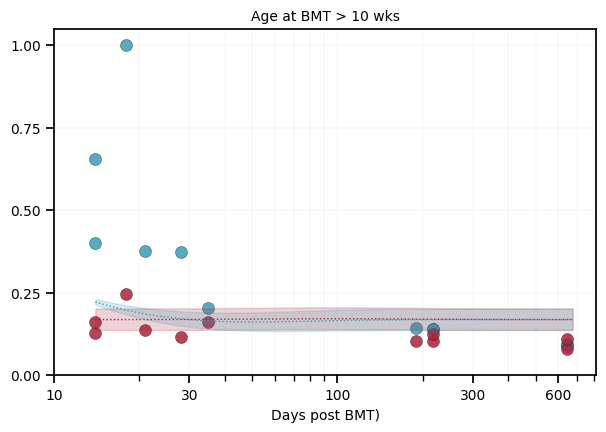

In [ ]:

plt.figure(figsize=(7, 4.5))
sns.scatterplot(data=df_Ki67_bin2, x='Days postBMT', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#3b9bb3')
sns.scatterplot(data=df_Ki67_bin2, x='Days postBMT', y='frac_Ki67+_MZ_host', edgecolor='black', linewidth=0.25, alpha=0.85, s=75, color='#ab2239')

# plt.plot(tb2, np.mean(data_neutral_T1.host_ki_pred2, axis=0), color='#ab2239', linestyle='dashed', linewidth=1)
# plt.fill_between(tb2, np.quantile(data_neutral_T1.host_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.host_ki_pred2, 0.975, axis=0), color= '#ab2239', alpha=0.2)
# plt.plot(tb2, np.mean(data_neutral_T1.donor_ki_pred2, axis=0), color = '#3b9bb3', linestyle='dashed', linewidth=1)
# plt.fill_between(tb2, np.quantile(data_neutral_T1.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_T1.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.2)


# plt.plot(tb2, np.mean(data_neutral_T2.host_ki_pred2 , axis=0), color='#ab2239', linewidth=1)
# plt.fill_between(tb2, np.quantile(data_neutral_T2.host_ki_pred2 , 0.025, axis=0), np.quantile(data_neutral_T2.host_ki_pred2, 0.975, axis=0), color='#ab2239', alpha=0.2)
# plt.plot(tb2, np.mean(data_neutral_T2.donor_ki_pred2, axis=0), color='#3b9bb3', linewidth=1)
# plt.fill_between(tb2, np.quantile(data_neutral_T2.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_T2.donor_ki_pred2, 0.975, axis=0), color='#3b9bb3', alpha=0.2)


plt.plot(tb2, np.mean(data_neutral_FO.host_ki_pred2 , axis=0), color = '#ab2239', linestyle='dotted', linewidth=1)
plt.fill_between(tb2, np.quantile(data_neutral_FO.host_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.host_ki_pred2 , 0.975, axis=0), color = '#ab2239', alpha=0.2)
plt.plot(tb2, np.mean(data_neutral_FO.donor_ki_pred2, axis=0), color='#3b9bb3', linestyle='dotted', linewidth=1)
plt.fill_between(tb2, np.quantile(data_neutral_FO.donor_ki_pred2, 0.025, axis=0), np.quantile(data_neutral_FO.donor_ki_pred2, 0.975, axis=0), color= '#3b9bb3', alpha=0.2)


# plt.xlim(50, 800)
plt.ylim(0, 1.05)
plt.xscale('log')
plt.xticks([10, 30, 100, 300, 600], [10, 30, 100, 300, 600])
plt.ylabel('')
plt.yticks(np.arange(0, 1.25, 0.25))
# plt.ylabel('Proportion of Ki67+ MZ cells', fontsize=12)
plt.title('Age at BMT > 10 wks', fontsize=10)
plt.xlabel('Days post BMT)', fontsize=10)
# plt.axhline(y=1, color='black', linestyle='dashed', linewidth=1)
plt.tick_params(axis='both', labelsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.25, alpha=0.3)  
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_Ki67Bin2_dpbmt_FO.pdf', dpi=300)
plt.show() 

In [ ]:
# # Plot against days post BMT

# tb1 = np.arange(52, 750,1) - 41
# plt.figure(figsize=(7, 4.5))
# sns.scatterplot(data=df_Ki67_bin2, x='Days postBMT', y='frac_Ki67+_MZ_donor', edgecolor='black', linewidth=0.5,alpha=0.85, s=75, color='#3b9bb3')
# sns.scatterplot(data=df_Ki67_bin2, x='Days postBMT', y='frac_Ki67+_MZ_host', edgecolor='black', linewidth=0.5, alpha=0.85, s=75, color='#ab2239')


# plt.plot(tb1, np.mean(data_neutral_T1.host_ki_pred1, axis=0),  color='#ab2239', linestyle='dashed')
# plt.fill_between(tb1, np.quantile(data_neutral_T1.host_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_T1.host_ki_pred1, 0.975, axis=0),  color='#ab2239', alpha=0.065)
# plt.plot(tb1, np.mean(data_neutral_T1.donor_ki_pred1, axis=0), color='#3b9bb3', linestyle='dashed')
# plt.fill_between(tb1, np.quantile(data_neutral_T1.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_T1.donor_ki_pred1, 0.975, axis=0), color='#3b9bb3', alpha=0.065)


# plt.plot(tb1, np.mean(data_neutral_T2.host_ki_pred1 , axis=0),  color='#ab2239')
# plt.fill_between(tb1, np.quantile(data_neutral_T2.host_ki_pred1 , 0.025, axis=0), np.quantile(data_neutral_T2.host_ki_pred1, 0.975, axis=0),  color='#ab2239', alpha=0.065)
# plt.plot(tb1, np.mean(data_neutral_T2.donor_ki_pred1, axis=0), color='#3b9bb3')
# plt.fill_between(tb1, np.quantile(data_neutral_T2.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_T2.donor_ki_pred1, 0.975, axis=0), color='#3b9bb3', alpha=0.065)


# plt.plot(tb1, np.mean(data_neutral_FO.host_ki_pred1, axis=0), color='#ab2239', linestyle='dotted')
# plt.fill_between(tb1, np.quantile(data_neutral_FO.host_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_FO.host_ki_pred1 , 0.975, axis=0), color= '#ab2239', alpha=0.065)
# plt.plot(tb1, np.mean(data_neutral_FO.donor_ki_pred1, axis=0), color='#3b9bb3', linestyle='dotted')
# plt.fill_between(tb1, np.quantile(data_neutral_FO.donor_ki_pred1, 0.025, axis=0), np.quantile(data_neutral_FO.donor_ki_pred1, 0.975, axis=0), color='#3b9bb3', alpha=0.065)


# plt.xlim(10, 800)
# plt.ylim(0, 1.05)
# plt.xscale('log')
# plt.xticks([10, 50, 150, 300, 600], [10, 50, 150, 300, 600])
# plt.ylabel('')
# plt.yticks(np.arange(0, 1.25, 0.25))
# # plt.ylabel('Proportion of Ki67+ MZ cells', fontsize=12)
# plt.title('Extent of cell division', fontsize=10)
# plt.xlabel('Days post BMT', fontsize=10)
# plt.tick_params(axis='both', labelsize=10)
# plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
# plt.legend(labels=['Donor', 'Host'])
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_Ki67_daypostBMT.pdf', dpi=300)

plt.show() 

Mean and standard deviation of the parameters:
rho_T1: 0.025343342619999997 0.0033756960355656334
phi_T1: 0.01885188046 0.002550193256496493
rho_T2: 0.02532994216 0.0032830190729842756
phi_T2: 0.01934511258 0.0027925623487628243
rho_FO: 0.029929173379999997 0.0035139017958283037
phi_FO: 0.0013040803408 0.0002064601242413262
kappa_0_T1: 0.162905019565 0.11284126991685751
y0_T1: 2482040.72 181572.9557828522
MZ_COUNT_T1 2482040.72 181572.9557828522
kappa_0_T2: 0.16322827228359998 0.11124876815664486
y0_T2: 2490341.448 194051.4573559892
MZ_COUNT_T2 2490341.448 194051.4573559892


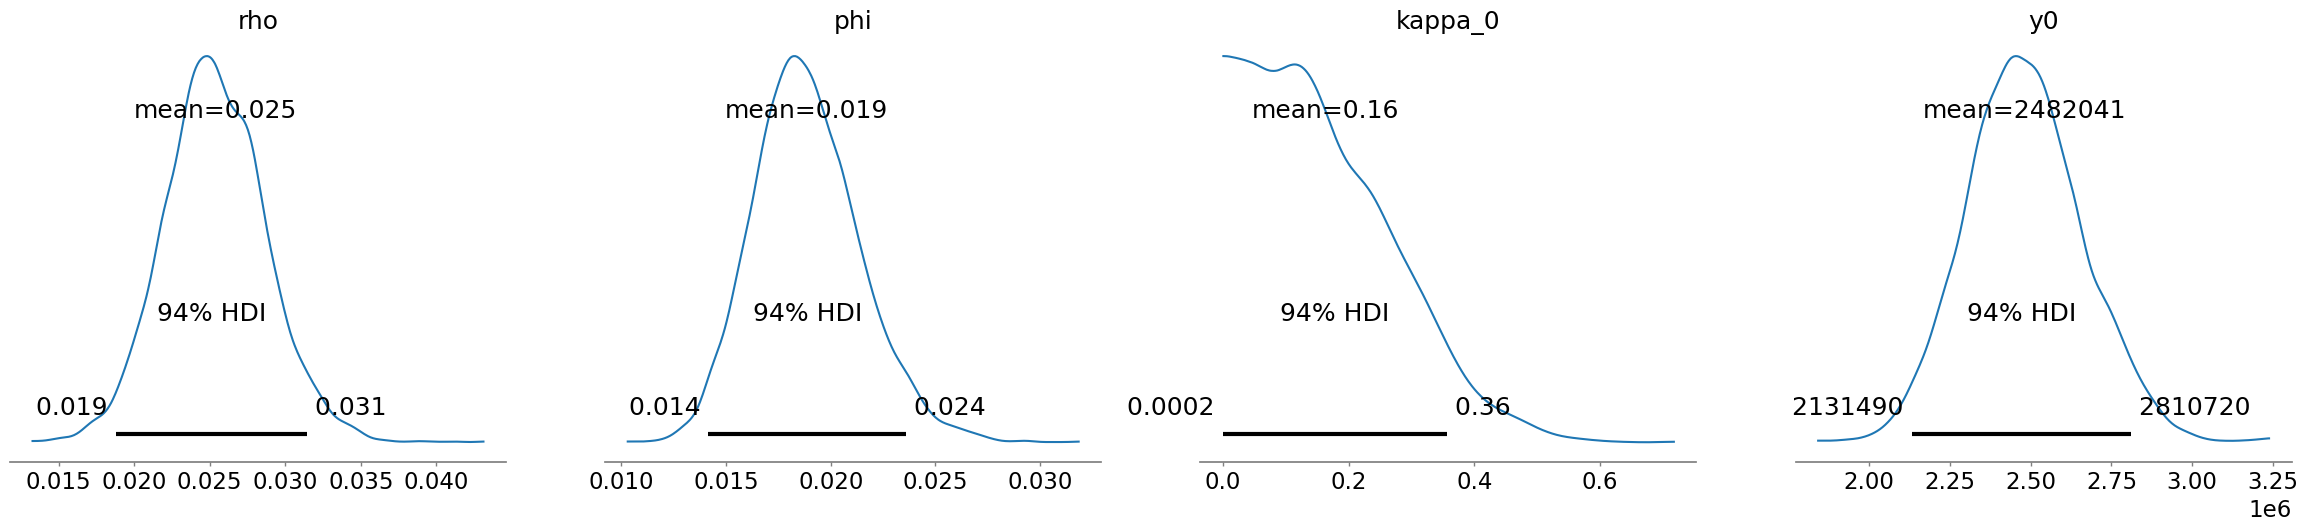

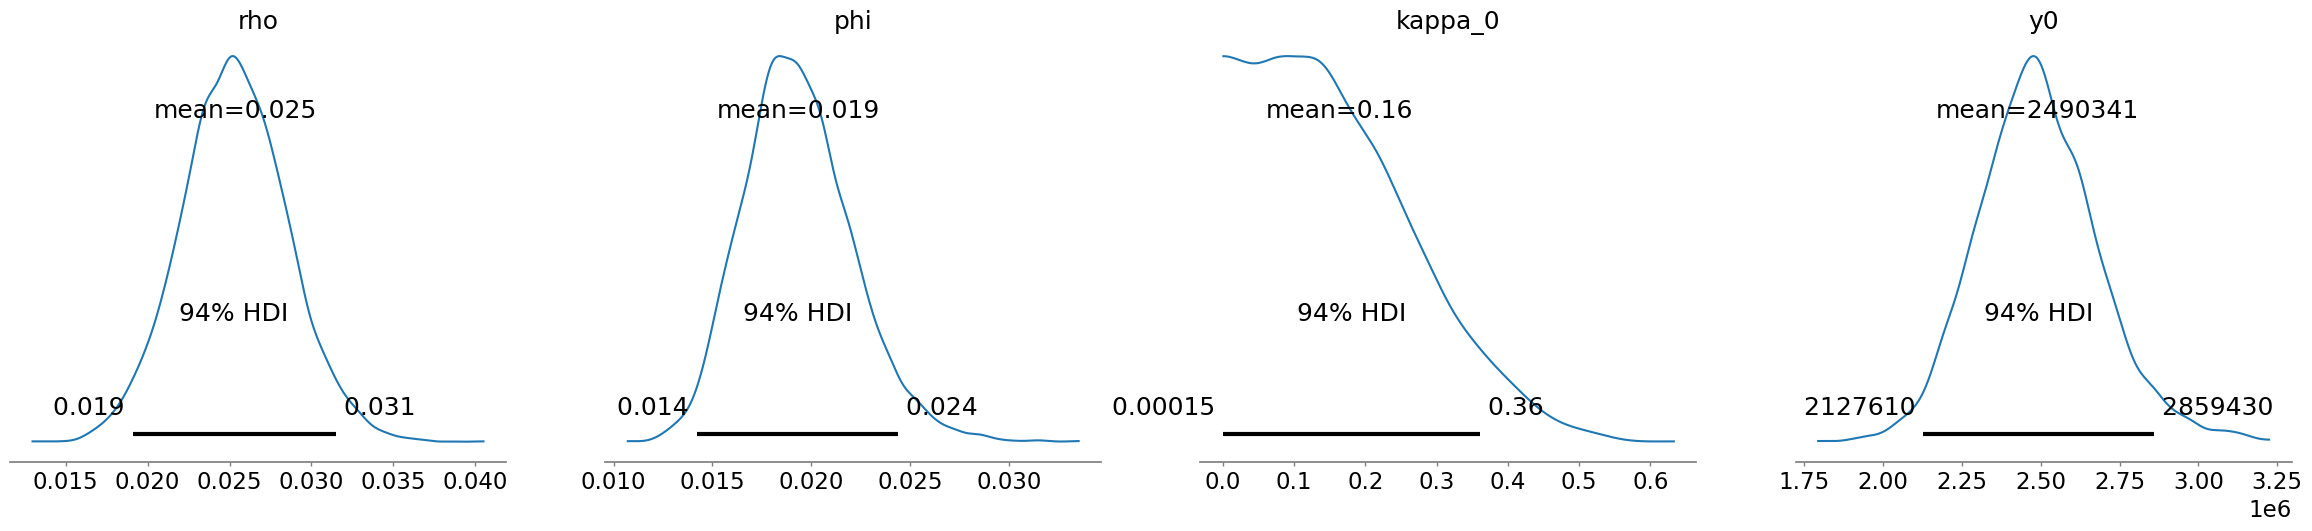

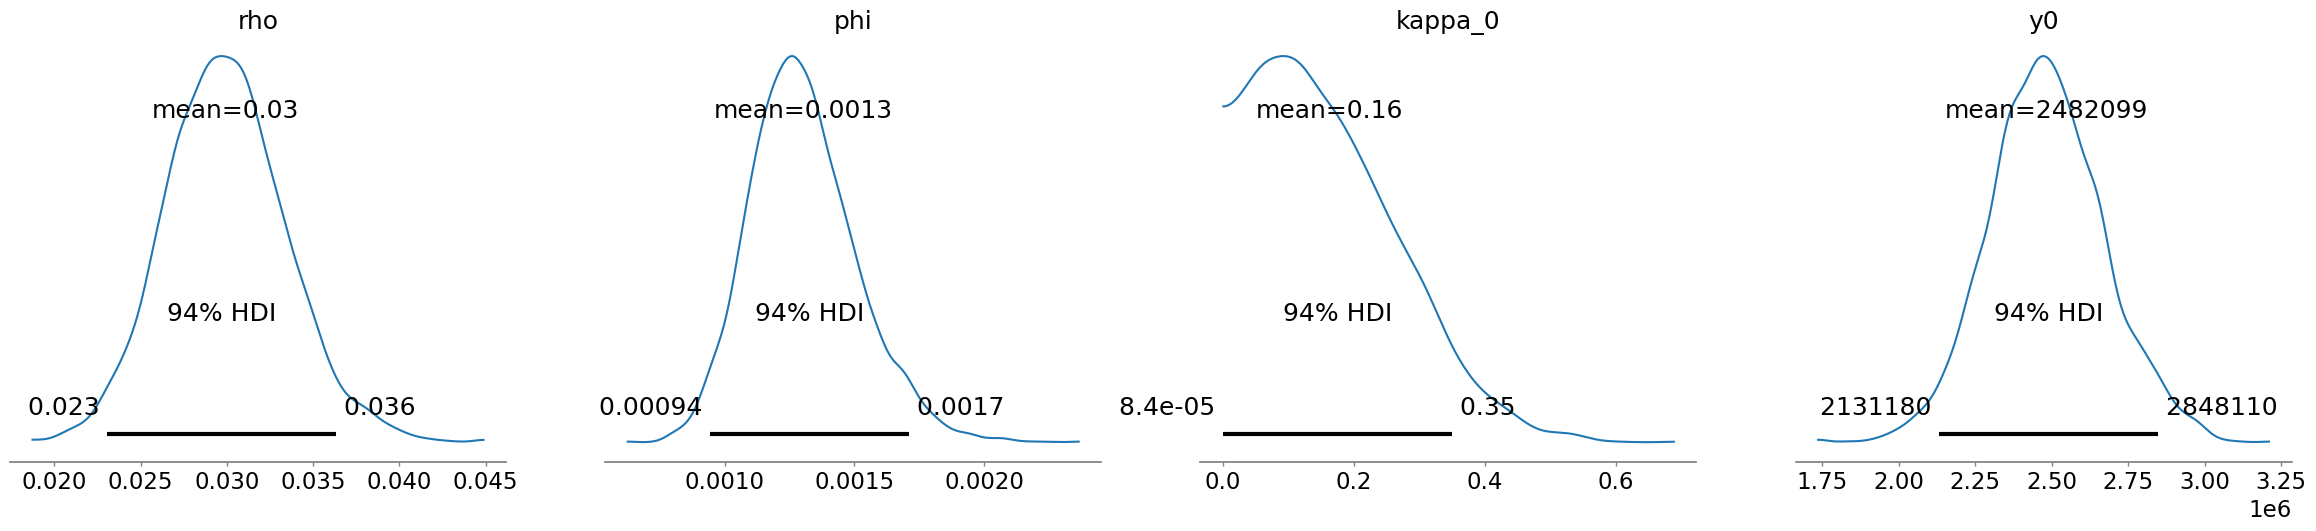

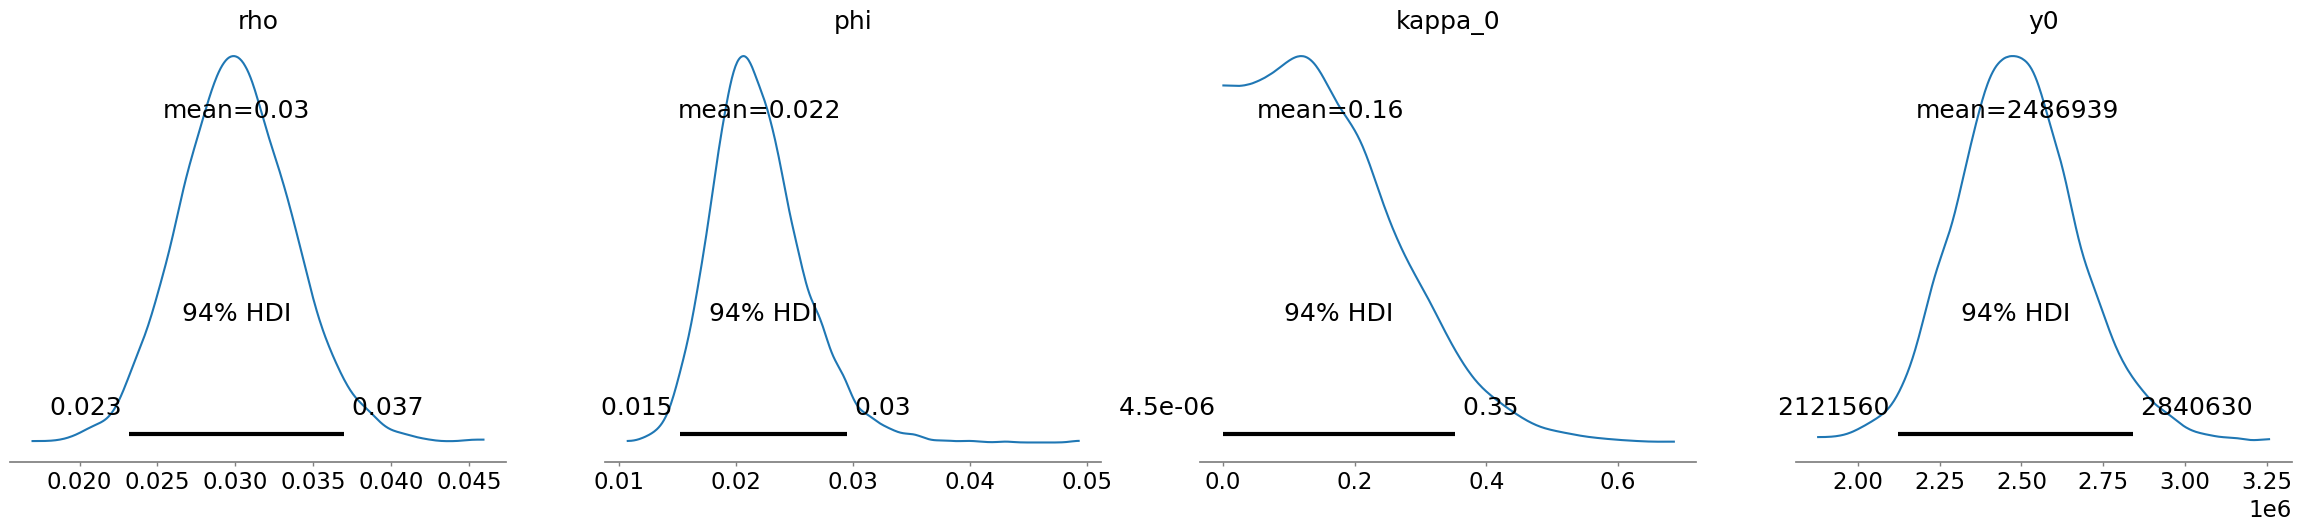

In [ ]:
az.plot_posterior(data_neutral_T1, var_names=['rho', 'phi','kappa_0', 'y0'], kind='kde')
az.plot_posterior(data_neutral_T2, var_names=['rho', 'phi','kappa_0', 'y0'], kind='kde')
az.plot_posterior(data_neutral_FO, var_names=['rho', 'phi','kappa_0', 'y0'], kind='kde')
az.plot_posterior(data_neutral_T2MZP, var_names=['rho', 'phi','kappa_0', 'y0'], kind='kde')




# az.plot_posterior(data_neutral, var_names=['rho', 'phi', 'r_d', 37'kappa_0', 'y0'], kind='kde')



# Print mean and standard deviation of the parameters
print("Mean and standard deviation of the parameters:")
print("rho_T1:", np.mean(data_neutral_T1.rho), np.std(data_neutral_T1.rho))
print("phi_T1:", np.mean(data_neutral_T1.phi), np.std(data_neutral_T1.phi))
print("rho_T2:", np.mean(data_neutral_T2.rho), np.std(data_neutral_T2.rho))
print("phi_T2:", np.mean(data_neutral_T2.phi), np.std(data_neutral_T2.phi))
print("rho_FO:", np.mean(data_neutral_FO.rho), np.std(data_neutral_FO.rho))
print("phi_FO:", np.mean(data_neutral_FO.phi), np.std(data_neutral_FO.phi))
# print("delta:", np.mean(data_neutral.delta), np.std(data_neutral.delta))
# print("lamda:", np.mean(data_neutral.lamda), np.std(data_neutral.lamda))
print("kappa_0_T1:", np.mean(data_neutral_T1.kappa_0), np.std(data_neutral_T1.kappa_0))
print("y0_T1:", np.mean(data_neutral_T1.y0), np.std(data_neutral_T1.y0))
print('MZ_COUNT_T1', np.mean(data_neutral_T1.MZ_counts_mean), np.std(data_neutral_T1.MZ_counts_mean))

print("kappa_0_T2:", np.mean(data_neutral_T2.kappa_0), np.std(data_neutral_T2.kappa_0))
print("y0_T2:", np.mean(data_neutral_T2.y0), np.std(data_neutral_T2.y0))
print('MZ_COUNT_T2', np.mean(data_neutral_T2.MZ_counts_mean), np.std(data_neutral_T2.MZ_counts_mean))

In [ ]:
#Plot error bars for daily influx across all models 
phi_samples = data_neutral_T1.stan_variable('phi')
rho_samples = data_neutral_T1.stan_variable('rho')
M_stable_samples = data_neutral_T1.stan_variable('MZ_counts_pred1')


phi_samples_T2 = data_neutral_T2.stan_variable('phi')
rho_samples_T2 = data_neutral_T2.stan_variable('rho')
M_stable_samples_T2 = data_neutral_T2.stan_variable('MZ_counts_pred1')

phi_samples_FO = data_neutral_FO.stan_variable('phi')
rho_samples_FO = data_neutral_FO.stan_variable('rho')
M_stable_samples_FO = data_neutral_FO.stan_variable('MZ_counts_pred1')

phi_samples_T2MZP = data_neutral_T2MZP.stan_variable('phi')
rho_samples_T2MZP = data_neutral_T2MZP.stan_variable('rho')
M_stable_samples_T2MZP = data_neutral_T2MZP.stan_variable('MZ_counts_pred1')



delta_T1 = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
delta_T2 = ((phi_samples_T2 * 1308516) / M_stable_samples_T2[:,0] ) + rho_samples_T2
delta_FO = ((phi_samples_FO * 27591715) / M_stable_samples_FO[:,0] ) + rho_samples_FO
delta_T2MZP = ((phi_samples_T2MZP * 1788129) / M_stable_samples_T2MZP[:,0] ) + rho_samples_T2MZP

print("Delta T1:", np.mean(delta_T1), np.std(delta_T1))
print("Delta T2:", np.mean(delta_T2), np.std(delta_T2))
print("Delta FO:", np.mean(delta_FO), np.std(delta_FO))
print("Delta T2MZP:", np.mean(delta_T2MZP), np.std(delta_T2MZP))


# Calulate Net loss 
net_loss_T1 = delta_T1 - rho_samples
net_loss_T2 = delta_T2 - rho_samples_T2
net_loss_FO = delta_FO - rho_samples_FO
net_loss_T2MZP = delta_T2MZP - rho_samples_T2MZP

print("Net loss T1:", np.mean(net_loss_T1), np.std(net_loss_T1))
print("Net loss T2:", np.mean(net_loss_T2), np.std(net_loss_T2))
print("Net loss FO:", np.mean(net_loss_FO), np.std(net_loss_FO))
print("Net loss T2MZP:", np.mean(net_loss_T2MZP), np.std(net_loss_T2MZP))
# Calculate R0
R0_T1 = rho_samples/ delta_T1
R0_T2 = rho_samples_T2 / delta_T2
R0_FO = rho_samples_FO / delta_FO
R0_T2MZP = rho_samples_T2MZP / delta_T2MZP


lambda_T2 = delta_T2 - rho_samples_T2
print("Lambda T2:", np.mean(lambda_T2), np.std(lambda_T2))


P_T1= phi_samples * 1298783
P_T2 = phi_samples_T2 * 1308516
P_FO = phi_samples_FO * 27591715  # 2D array (n_samples, n_timepoints)

# # P_T2MZP = phi_samples_T2MZP * 1788129


# # Interdivision time
interdivision_time_T1 = 1 / rho_samples
interdivision_time_T2 = 1 / rho_samples_T2
interdivision_time_FO = 1 / rho_samples_FO
# interdivision_time_T2MZP = 1 / rho_samples_T2MZP

# Residence time
residence_time_T1 = 1 / delta_T1
residence_time_T2 = 1 / delta_T2
residence_time_FO = 1 / delta_FO

# residence_time_T2MZP = 1 / delta_T2MZP

# Turnover time 
turnover_time_T1 = 1/ (delta_T1 - rho_samples)
turnover_time_T2 = (np.log(M_stable_samples_T2[:, 0]))/ (delta_T2)
turnover_time_FO = 1/ (delta_FO - rho_samples_FO)


#Clonal halflife
clonal_halflife_T1 = np.log(2) / (delta_T1 - rho_samples)
clonal_halflife_T2 = np.log(2) / (delta_T2 - rho_samples_T2)
clonal_halflife_FO = np.log(2) / (delta_FO - rho_samples_FO)
# clonal_halflife_T2MZP

print(np.mean(M_stable_samples_T2[:,0]), np.std(M_stable_samples_T2[:,0]))
print(np.mean(M_stable_samples[:,0]), np.std(M_stable_samples[:,0]))
print(np.mean(M_stable_samples_FO[:,0]), np.std(M_stable_samples_FO[:,0]))



Delta T1: 0.035206843765532826 0.003439486304646206
Delta T2: 0.03549452540139515 0.0033722819047616675
Delta FO: 0.04442733466277348 0.0040991816417679855
Delta T2MZP: 0.04589829628964412 0.004599395359672507
Net loss T1: 0.009863501145532834 0.0011087169288994843
Net loss T2: 0.010164583241395155 0.001228028818642235
Net loss FO: 0.01449816128277348 0.0020225648108830353
Net loss T2MZP: 0.015814899489644124 0.002546498723068787
Lambda T2: 0.010164583241395155 0.001228028818642235
2490341.448 194051.4573559892
2482040.72 181572.9557828522
2482098.742 188254.77701677967


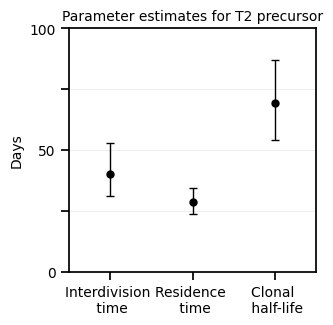

Interdivision time T2: 40.16734388869979 5.421074727215162
Residence time T2: 28.43164720447889 2.7466684997187922
Clonal half-life T2: 69.18282657397822 8.33544201914696


In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(3.6, 3.6))

# Plot daily influx for each model with different colors
colors = ['Black', 'Black', 'Black']
models = [interdivision_time_T2, residence_time_T2, clonal_halflife_T2]
labels = ['Interdivision \n time', 'Residence \n time', 'Clonal \n half-life']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    # Ensure perfect centering by explicitly setting x position
    x_pos = float(i)  # Convert to float to ensure exact positioning
    
    ax.errorbar(x_pos, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=3, markersize=5, elinewidth=1,
                label=label)

ax.set_ylabel('Days', fontsize=10)
ax.set_ylim(0, 100)
# set_yticks and set_yticklabels must be called separately
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_yticklabels(['0', '', '50', '', '100'], fontsize=10)

ax.set_title('Parameter estimates for T2 precursor', fontsize=10)

# Ensure x-ticks are exactly centered
ax.set_xticks([0.0, 1.0, 2.0])  # Explicitly set as floats
ax.set_xticklabels(labels, fontsize=10, ha='center')
ax.set_xlim(-0.5, 2.5)  # Add some padding on sides

ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Chimera_T2_parameters.pdf', dpi=300)
plt.show()

print("Interdivision time T2:", np.mean(interdivision_time_T2), np.std(interdivision_time_T2))
print("Residence time T2:", np.mean(residence_time_T2), np.std(residence_time_T2))
print("Clonal half-life T2:", np.mean(clonal_halflife_T2), np.std(clonal_halflife_T2))

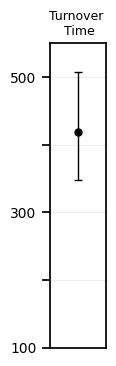

In [ ]:
#Plot influx as a fraction of MZ time 

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=3, markersize=5, elinewidth=1)
    
fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))
plot_with_error_bars(turnover_time_T2, '' ,'black', ax)
ax.set_ylim(100, 550)
ax.set_yticks([100, 200, 300, 400, 500])
ax.set_yticklabels(['100', '', '300', '', '500'], fontsize=10)
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Turnover \n Time', fontsize=9)
# ax.set_xlabel('Turnover \n Time', fontsize=10)

ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/Turnover_Time_T2.pdf', dpi=300)
plt.show()

/var/folders/ps/wzpv12c53fsgbwcd_wt33b5r0000gn/T/ipykernel_14052/3676868527.py:29: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


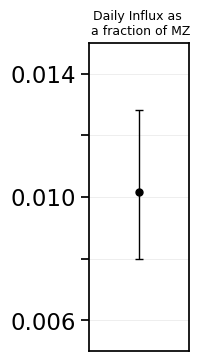

In [ ]:
#Plot turnover time 

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=3, markersize=5, elinewidth=1)
    
fig, ax = plt.subplots(1, 1, figsize=(1.3, 4))
plot_with_error_bars(P_T2/M_stable_samples_T2[:,0] , '' ,'black', ax)
ax.set_ylim(0.005, 0.015)
# ax.set_yticks([1.5e4, 2.5e4, 3.5e4])
ax.set_yticks([0.006, 0.008, 0.010, 0.012, 0.014], ['0.006', '', '0.010', '', '0.014'])
ax.set_xticklabels([])
ax.set_xticks([])
ax.set_title('Daily Influx as \n a fraction of MZ', fontsize=9)
# ax.set_xlabel('Turnover \n Time', fontsize=10)


ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)
plt.tight_layout()
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Daily_Influx_fractionofMZ_T2.pdf', dpi=300)
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_T1_T2_parameters_V2.pdf'

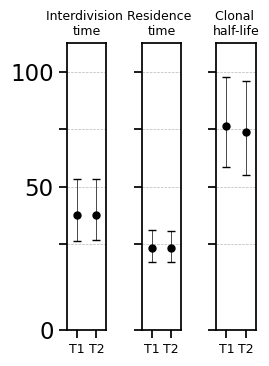

In [ ]:
def plot_with_error_bars(data, color, ax, marker='o', label=None):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_data, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt=marker, color=color, capsize=3, markersize=5, elinewidth=1, label=label)

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(3, 4))

# Plot T1 and T2 with different markers and slight x-offset for clarity
x_offset = 0.5

# Interdivision time
axes[0].errorbar(-x_offset, np.mean(interdivision_time_T1), 
                yerr=[[np.mean(interdivision_time_T1) - np.quantile(interdivision_time_T1, 0.025)], 
                      [np.quantile(interdivision_time_T1, 0.975) - np.mean(interdivision_time_T1)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='T1')

axes[0].errorbar(x_offset, np.mean(interdivision_time_T2), 
                yerr=[[np.mean(interdivision_time_T2) - np.quantile(interdivision_time_T2, 0.025)], 
                      [np.quantile(interdivision_time_T2, 0.975) - np.mean(interdivision_time_T2)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='T2')

# Residence time
axes[1].errorbar(-x_offset, np.mean(residence_time_T1), 
                yerr=[[np.mean(residence_time_T1) - np.quantile(residence_time_T1, 0.025)], 
                      [np.quantile(residence_time_T1, 0.975) - np.mean(residence_time_T1)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='T1')

axes[1].errorbar(x_offset, np.mean(residence_time_T2), 
                yerr=[[np.mean(residence_time_T2) - np.quantile(residence_time_T2, 0.025)], 
                      [np.quantile(residence_time_T2, 0.975) - np.mean(residence_time_T2)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='T2')

# Clonal half-life
axes[2].errorbar(-x_offset, np.mean(clonal_halflife_T1), 
                yerr=[[np.mean(clonal_halflife_T1) - np.quantile(clonal_halflife_T1, 0.025)], 
                      [np.quantile(clonal_halflife_T1, 0.975) - np.mean(clonal_halflife_T1)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='T1')

axes[2].errorbar(x_offset, np.mean(clonal_halflife_T2), 
                yerr=[[np.mean(clonal_halflife_T2) - np.quantile(clonal_halflife_T2, 0.025)], 
                      [np.quantile(clonal_halflife_T2, 0.975) - np.mean(clonal_halflife_T2)]], 
                fmt='o', color='black', capsize=3, markersize=5, elinewidth=0.5, label='T2')

# Formatting
for i, ax in enumerate(axes):
    ax.set_ylim(0, 100)
    ax.set_yticks([0, 30, 50, 70, 90])
    ax.set_xticks([])
    ax.set_xlim(-1, 1)
    ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

axes[0].set_yticklabels([0, '', 50, '', 100])
axes[0].set_title('Interdivision \ntime', fontsize=9)
# axes[0].legend(fontsize=8, loc='upper right')

# place xticks under the two plotted points and label them explicitly
axes[0].set_xticks([-x_offset, x_offset])
axes[0].set_xticklabels(['T1', 'T2'], fontsize=9)

axes[1].set_yticklabels([])
axes[1].set_title('Residence \ntime', fontsize=9)
axes[1].set_xticks([-x_offset, x_offset])
axes[1].set_xticklabels(['T1', 'T2'], fontsize=9)

axes[2].set_yticklabels([])
axes[2].set_title('Clonal \nhalf-life', fontsize=9)
axes[2].set_xticks([-x_offset, x_offset])
axes[2].set_xticklabels(['T1', 'T2'], fontsize=9)

# Adjust layout
plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_T1_T2_parameters_V2.pdf', dpi=300)
plt.show()

In [ ]:
#Plot P_FO against time

plt.figure(figsize=(6, 4))
mean_P_FO = np.mean(P_FO, axis=0)
lower_ci_P_FO = np.quantile(P_FO, 0.025, axis=0)
upper_ci_P_FO = np.quantile(P_FO, 0.975, axis=0)    
plt.plot(ts, mean_P_FO, color='black')
plt.fill_between(ts, lower_ci_P_FO, upper_ci_P_FO, color='black', alpha=0.2)
plt.xlim(50, 800)
plt.ylim(20000, 70000)
plt.xscale('log')       
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('Daily influx from FO B cells', fontsize=10)
plt.xlabel('Host age (days)', fontsize=10)
plt.title('Daily influx of FO B cells into MZ B', fontsize=10)
plt.tick_params(axis='both', labelsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_P_FO.pdf', dpi=300)
plt.show()


NameError: name 'ts' is not defined

<Figure size 600x400 with 0 Axes>

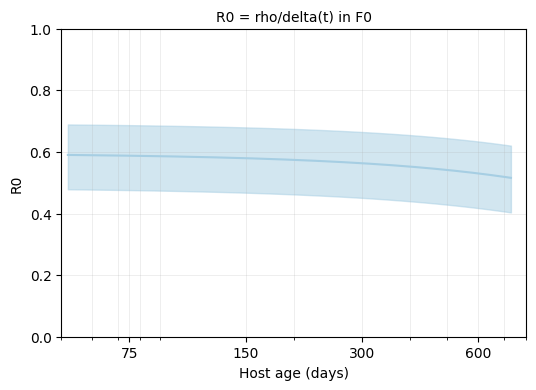

In [ ]:
#Plot R0 against time

plt.figure(figsize=(6, 4))
mean_R0_FO = np.mean(R0_FO, axis=0)
lower_ci_R0_FO = np.quantile(R0_FO, 0.025, axis=0)
upper_ci_R0_FO = np.quantile(R0_FO, 0.975, axis=0)    
plt.plot(ts, mean_R0_FO, color='#a6cee3')
plt.fill_between(ts, lower_ci_R0_FO, upper_ci_R0_FO, color='#a6cee3', alpha=0.5)
plt.xlim(50, 800)
plt.ylim(0, 1)
plt.xscale('log')       
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('R0', fontsize=10)
plt.xlabel('Host age (days)', fontsize=10)      
plt.title('R0 = rho/delta(t) in F0', fontsize=10)
plt.tick_params(axis='both', labelsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_R0_FO.pdf', dpi=300)
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

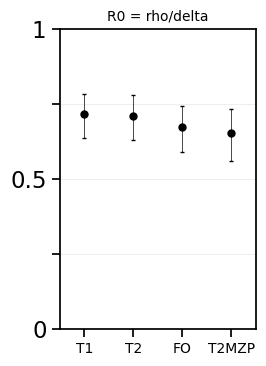

In [ ]:
#Plot residence time
fig, ax = plt.subplots(1, 1, figsize=(3, 4))
# Plot daily influx for each model with different colors
colors = ['black', 'black', 'black', 'black']
models = [R0_T1, R0_T2, R0_FO, R0_T2MZP]
labels = ['T1', 'T2', 'FO', 'T2MZP']
for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color,capsize=1.5, markersize=5, elinewidth=0.5,
                label=label)    
# ax.set_ylabel('Days', fontsize=10)
plt.ylim(0, 1)
ax.set_xlim(-0.5, 3.5)  # Add some padding on sides
ax.set_yticks([0, 0.25, 0.5, 0.75, 1], [0, '', 0.5, '', 1])
# ax.set_xlabel('Model', fontsize=15)
# ax.set_yscale('log')      
ax.set_title('R0 = rho/delta', fontsize=10)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=10, ha='center')
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.3)    
plt.tight_layout()
plt.savefig('/Users/apoorvasingh/Desktop/MZB-new-analysis/figures/R0_allprecursors.pdf', dpi=300)
plt.show

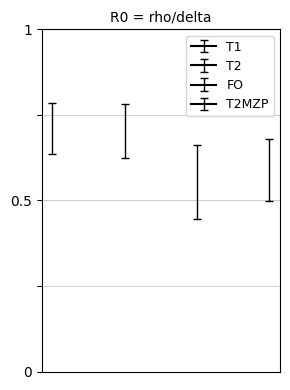

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(3, 4))

colors = ['Black', 'Black', 'Black', 'Black']
models = [R0_T1, R0_T2, R0_FO, R0_T2MZP]
labels = ['T1', 'T2', 'FO', 'T2MZP']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    x_pos = float(i)


    ax.errorbar(x_pos, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
               color=color, capsize=3, markersize=5, elinewidth=1,
                label=label)


# Plot the mean FO line connecting the last 5 FO points



ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1], [0, '', 0.5, '', 1])
ax.set_title('R0 = rho/delta', fontsize=10)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
ax.legend( ['T1', 'T2', 'FO', 'T2MZP'], fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_R0.pdf', dpi=300)
plt.show()

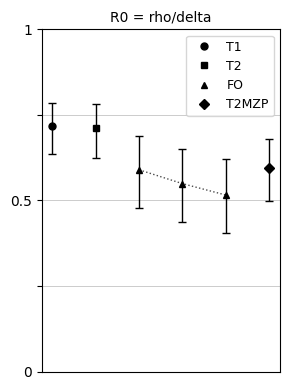

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(3, 4))

colors = ['Black', 'Black', 'Black', 'Black', 'Black', 'Black']
models = [R0_T1, R0_T2, R0_FO_59, R0_FO_430, R0_FO_731, R0_T2MZP]
labels = ['T1', 'T2', 'FO (age 59d)', 'FO (age 430d)', 'FO (age 731d)', 'T2MZP']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    x_pos = float(i)
    
    # Set different markers and capstyles based on model type
    if 'T1' in label:
        marker = 'o'
        markersize = 5
    elif 'T2' in label and 'T2MZP' not in label:  # Make sure T2 doesn't match T2MZP
        marker = 's'  # square marker for T2
        markersize = 5
    elif 'T2MZP' in label:
        marker = 'D'  # diamond marker for T2MZP
        markersize = 5
    else:  # FO models
        marker = '^'  # triangle marker for FO
        markersize = 5

    ax.errorbar(x_pos, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt=marker, color=color, capsize=3, markersize=markersize, elinewidth=1)

# Plot the mean FO line connecting the FO points
fo_x_positions = [2, 3, 4]  # x positions for the 3 FO models
fo_mean_values = [np.mean(R0_FO_59), np.mean(R0_FO_430), np.mean(R0_FO_731)]

plt.plot(fo_x_positions, fo_mean_values, color='black', linestyle='dotted', linewidth=1, alpha=0.7)

ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([0, 0.25, 0.5, 0.75, 1], [0, '', 0.5, '', 1])
ax.set_title('R0 = rho/delta', fontsize=10)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)

# Create legend manually to avoid duplicate labels
handles = [
    plt.Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=5, label='T1'),
    plt.Line2D([0], [0], marker='s', color='black', linestyle='None', markersize=5, label='T2'),
    plt.Line2D([0], [0], marker='^', color='black', linestyle='None', markersize=5, label='FO'),
    plt.Line2D([0], [0], marker='D', color='black', linestyle='None', markersize=5, label='T2MZP')
]
ax.legend(handles=handles, fontsize=9, loc='upper right')

plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_R0.pdf', dpi=300)
plt.show()

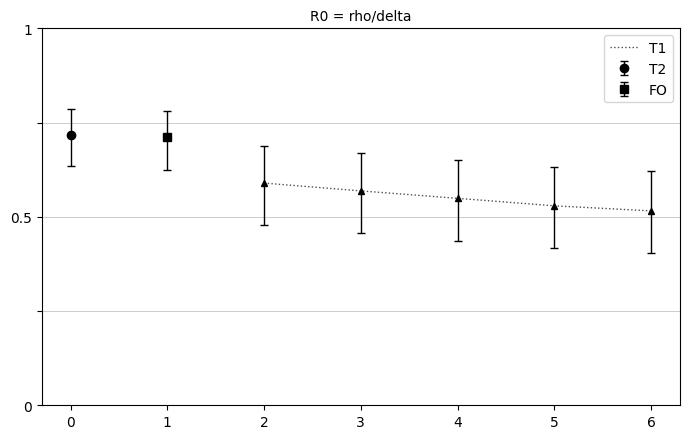

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(7, 4.5))

colors = ['Black', 'Black', 'Black', 'Black', 'Black', 'Black', 'Black']
models = [R0_T1, R0_T2, R0_FO_59, R0_FO_250, R0_FO_430, R0_FO_610, R0_FO_731]
labels = ['T1', 'T2', 'FO (age 59d)', 'FO (age 250d)', 'FO (age 430d)', 'FO (age 610d)', 'FO (age 731d)']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    x_pos = float(i)
    
    # Different markers for different model types
    if 'T1' in label:
        marker = 'o'
        markersize = 6
    elif 'T2' in label:
        marker = 's'
        markersize = 6
    else:  # FO models
        marker = '^'
        markersize = 4
    
    ax.errorbar(x_pos, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt=marker, color=color, capsize=3, markersize=markersize, elinewidth=1,
                label=label)

# Plot the mean FO line connecting the last 5 FO points
fo_x_positions = [2, 3, 4, 5, 6]  # x positions for the 5 FO models
fo_mean_values = [np.mean(R0_FO_59), np.mean(R0_FO_250), np.mean(R0_FO_430), np.mean(R0_FO_610), np.mean(R0_FO_731)]

plt.plot(fo_x_positions, fo_mean_values, color='black', linestyle='dotted', linewidth=1, alpha=0.7)

ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1], [0, '', 0.5, '', 1])
ax.set_title('R0 = rho/delta', fontsize=10)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
ax.legend( ['T1', 'T2', 'FO'], fontsize=10, loc='upper right')
plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_R0.pdf', dpi=300)
plt.show()

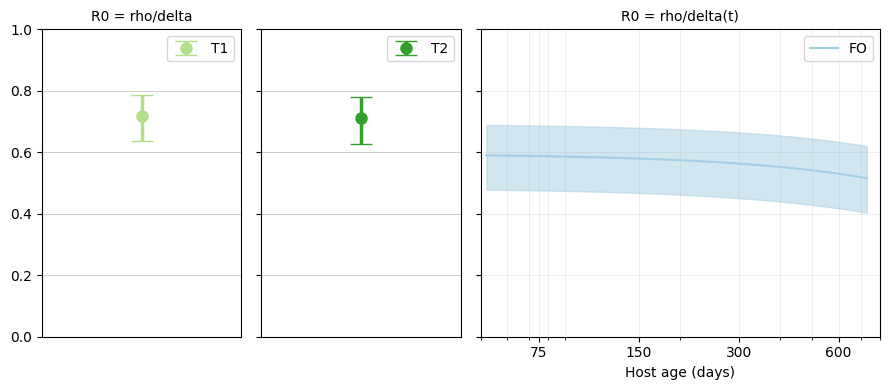

In [ ]:
# Create three separate subplots for R0 comparison
from matplotlib.pylab import save


fig, axes = plt.subplots(1, 3, figsize=(9, 4),  gridspec_kw={'width_ratios': [1, 1, 2]})

# Colors for each model
colors = ['#b2df8a', '#33a02c', '#a6cee3']
models = [R0_T1, R0_T2, R0_FO]
labels = ['T1', 'T2', 'FO']

# Plot T1 and T2 as error bars (single values)
for i, (model_data, color, label) in enumerate(zip([R0_T1, R0_T2], colors[:2], labels[:2])):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    axes[i].errorbar(0, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                    fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5)
    
    axes[i].set_ylim(0, 1) 
    # axes[i].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Set tick positions for grid
    # axes[i].set_yticklabels([])  # Remove tick labels but keep positions for
 
    axes[i].set_xticks([])
    axes[i].yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)
    if i == 0:
        # axes[i].set_ylabel('R0', fontsize=10)
        axes[i].set_ylim(0, 1) 
        axes[i].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Set tick positions for grid 
        axes[i].legend(labels=['T1'], fontsize=10, loc='upper right')
        axes[i].set_title(f'R0 = rho/delta', fontsize=10)
    else:
        axes[i].set_yticklabels([])  # Remove tick labels but keep positions for grid
        axes[i].legend(labels=['T2'], fontsize=10, loc='upper right')

# Plot FO as time series (larger subplot)
mean_R0_FO = np.mean(R0_FO, axis=0)
lower_ci_R0_FO = np.quantile(R0_FO, 0.025, axis=0)
upper_ci_R0_FO = np.quantile(R0_FO, 0.975, axis=0)

axes[2].plot(ts, mean_R0_FO, color='#a6cee3')
axes[2].fill_between(ts, lower_ci_R0_FO, upper_ci_R0_FO, color='#a6cee3', alpha=0.5)
axes[2].set_xlim(50, 800)
axes[2].set_ylim(0, 1)
axes[2].set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Set tick positions for grid
axes[2].set_yticklabels([])  # Remove tick labels but keep positions for grid
axes[2].set_xscale('log')
axes[2].set_xticks([75, 150, 300, 600])
axes[2].set_xticklabels([75, 150, 300, 600])
axes[2].set_xlabel('Host age (days)', fontsize=10)
axes[2].set_title('R0 = rho/delta(t)', fontsize=10)
axes[2].grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
axes[2].legend(labels=['FO'], fontsize=10, loc='upper right')
fig.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_R0_comparison.pdf', dpi=300)
plt.tight_layout()
plt.show()

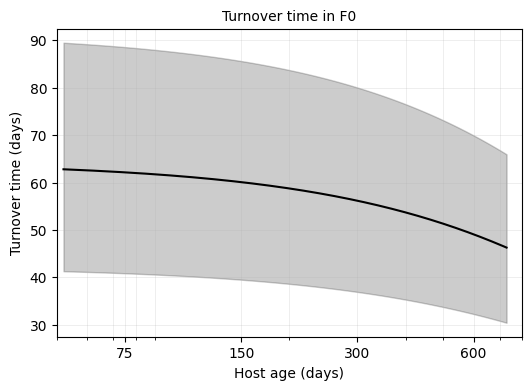

In [ ]:
# Plot turnover time for FO model

plt.figure(figsize=(6, 4))
mean_turnover_FO = np.mean(turnover_time_FO, axis=0)
lower_ci_turnover_FO = np.quantile(turnover_time_FO, 0.025, axis=0)
upper_ci_turnover_FO = np.quantile(turnover_time_FO, 0.975, axis=0)    
plt.plot(ts, mean_turnover_FO, color='black')
plt.fill_between(ts, lower_ci_turnover_FO, upper_ci_turnover_FO, color='black', alpha=0.2)
plt.xlim(50, 800)
# plt.ylim(1, 3)
plt.xscale('log')       
plt.xticks([75, 150,  300,  600], [75, 150,  300,  600])
plt.ylabel('Turnover time (days)', fontsize=10)
plt.xlabel('Host age (days)', fontsize=10)      
plt.title('Turnover time in F0', fontsize=10)
plt.tick_params(axis='both', labelsize=10)
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)  
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_R0_FO.pdf', dpi=300)
plt.show()


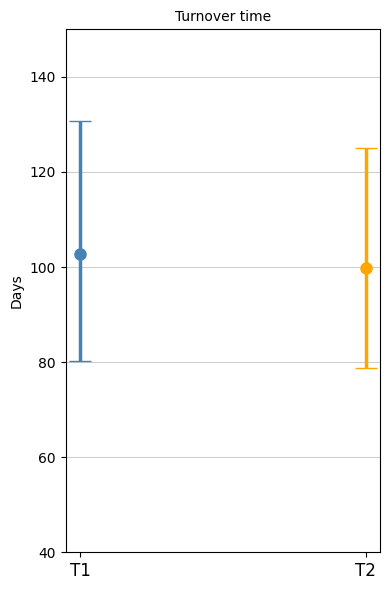

In [ ]:
# Plot error bars for turnover rate T1 and T2 models

fig, ax = plt.subplots(1, 1, figsize=(4, 6))
# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange']
models = [turnover_time_T1, turnover_time_T2]
labels = ['T1', 'T2']     
for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):    
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Days', fontsize=10)
plt.ylim(40, 150)
# ax.set_xlabel('Model', fontsize=15)
# ax.set_yscale('log')    
ax.set_title('Turnover time', fontsize=10)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)    
plt.tight_layout()
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_turnover_time.pdf', dpi=300)
plt.show()

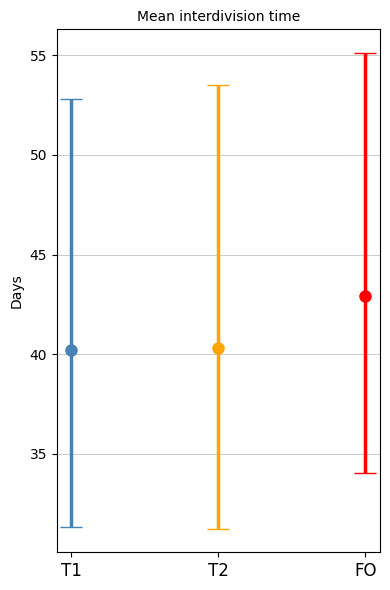

In [ ]:
#Plot residence time
fig, ax = plt.subplots(1, 1, figsize=(4, 6))
# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'red']
models = [interdivision_time_T1, interdivision_time_T2, interdivision_time_FO]
labels = ['T1', 'T2', 'FO']     
for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)    
ax.set_ylabel('Days', fontsize=10)
# ax.set_xlabel('Model', fontsize=15)
# ax.set_yscale('log')      
ax.set_title('Mean interdivision time', fontsize=10)
ax.set_xticks(range(3))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)    
plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_interdivision_time.pdf', dpi=300)
plt.show()

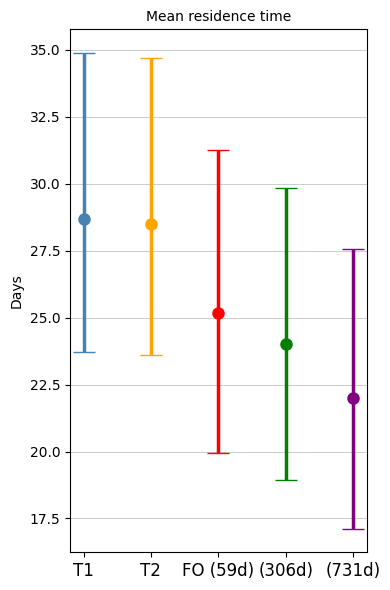

In [ ]:
#Plot residence time
fig, ax = plt.subplots(1, 1, figsize=(4, 6))
# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'red', 'green', 'purple']
models = [residence_time_T1, residence_time_T2, residence_time_FO_59, residence_time_FO_306, residence_time_FO_731]
labels = ['T1', 'T2', 'FO (59d)', '(306d)', '(731d)']     
for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)    
ax.set_ylabel('Days', fontsize=10)
# ax.set_xlabel('Model', fontsize=15)
# ax.set_yscale('log')      
ax.set_title('Mean residence time', fontsize=10)
ax.set_xticks(range(5))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)    
plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_residence_time.pdf', dpi=300)
plt.show()

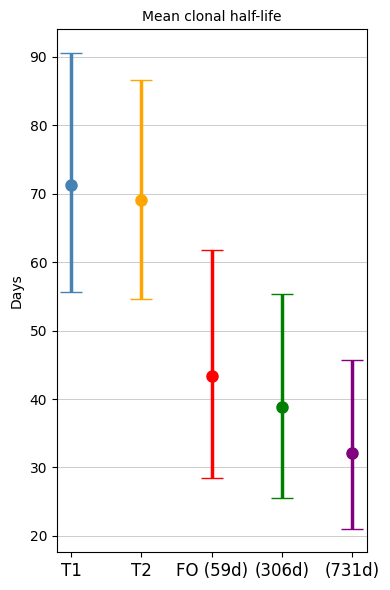

In [ ]:
# Calculate clonal half-lives

#Plot residence time
fig, ax = plt.subplots(1, 1, figsize=(4, 6))
# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'red', 'green', 'purple']
models = [clonal_halflife_T1, clonal_halflife_T2, clonal_halflife_FO_59, clonal_halflife_FO_306, clonal_halflife_FO_731]
labels = ['T1', 'T2', 'FO (59d)', '(306d)', '(731d)']     
for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)    
ax.set_ylabel('Days', fontsize=10)
# ax.set_xlabel('Model', fontsize=15)
# ax.set_yscale('log')      
ax.set_title('Mean clonal half-life', fontsize=10)
ax.set_xticks(range(5))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='-', linewidth=0.5, alpha=0.9)    
plt.tight_layout()
plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/Chimera_clonal_halflife.pdf', dpi=300)
plt.show()


In [ ]:
from scipy.integrate import solve_ivp

def chi_source(time):
    """Chimerism source function"""
    chi_est = 0.83
    nu = 0.083
    t0 = 10
    
    if (time - t0) < 0:
        chi_s = 0
    else:
        chi_s = chi_est * (1 - np.exp(-nu * (time - t0)))
    
    return chi_s

def ode_system(t, X, phi, rho, age_at_bmt):
    """System of ODEs for MZ B cell dynamics"""
    P = 1298783
    eps_donor = 0.98
    eps_host = 0.95
    beta = 4.5
    
    M_stable = np.sum(X)
    delta = ((phi * P) / M_stable) + rho
    
    chi = chi_source(t - age_at_bmt)
    
    dXdt = np.zeros(4)
    
    # Donor Ki67+ cells
    dXdt[0] = (phi * eps_donor * chi * P 
               + rho * (X[0] + 2 * X[1]) 
               - ((1/beta) + delta) * X[0])
    
    # Donor Ki67- cells  
    dXdt[1] = (phi * (1 - eps_donor) * chi * P 
               + (1/beta) * X[0] 
               - (rho + delta) * X[1])
    
    # Host Ki67+ cells
    dXdt[2] = (phi * eps_host * (1 - chi) * P 
               + rho * (X[2] + 2 * X[3]) 
               - ((1/beta) + delta) * X[2])
    
    # Host Ki67- cells
    dXdt[3] = (phi * (1 - eps_host) * (1 - chi) * P 
               + (1/beta) * X[2] 
               - (rho + delta) * X[3])
    
    return dXdt

def solve_multiple_trajectories(initial_cond_t40, bmt_ages, solve_times, phi, rho):
    
    solutions = []
    
    for i, (bmt_age, solve_start) in enumerate(zip(bmt_ages, solve_times)):
        # Step 1: Generate initial conditions at BMT age from t=40
        ic_solution = solve_ivp(
            ode_system, (40, bmt_age), initial_cond_t40, args=(phi, rho, bmt_age)
        )
        initial_at_bmt = ic_solution.y[:, -1]
        
        # Step 2: Set up conditions at BMT
        y0_bmt = np.zeros(4)
        y0_bmt[0] = 0  # donor Ki67+ = 0
        y0_bmt[1] = 0  # donor Ki67- = 0  
        y0_bmt[2] = initial_at_bmt[0] + initial_at_bmt[2]  # host Ki67+ 
        y0_bmt[3] = initial_at_bmt[1] + initial_at_bmt[3]  # host Ki67-
        
        # Step 3: Solve from BMT to t=750
        time_points = np.arange(solve_start, 751, 1)
        trajectory_solution = solve_ivp(
            ode_system, (bmt_age, 750), y0_bmt, 
            t_eval=time_points, args=(phi, rho, bmt_age)
        )
        
        # Step 4: Calculate donor fraction (fix the calculation)
        donor_cells = trajectory_solution.y[0, :] + trajectory_solution.y[1, :]  # Total donor
        total_cells = np.sum(trajectory_solution.y, axis=0)  # Total cells at each time
        chi_factor = chi_source(solve_start - bmt_age)
        
        nfd_values = donor_cells / (total_cells * chi_factor)
        mean_nfd_value = np.mean(nfd_values)
        quantiles_nfd_lower = np.quantile(nfd_values, 0.025)
        quantiles_nfd_upper = np.quantile(nfd_values, 0.975)
        
        solutions = pd.DataFrame({
            'mean': mean_nfd_value,
            'quantiles_lower': quantiles_nfd_lower,
            'quantiles_upper': quantiles_nfd_upper,
            'age_at_bmt': bmt_age
        })
    
    return solutions

# For integration with your Bayesian analysis:
def solve_for_parameter_samples(initial_cond_t40, bmt_ages, solve_times, phi, rho):
    """
    Solve trajectories for multiple parameter samples (for Bayesian uncertainty)
    """
    n_samples = len(phi)
    all_solutions = []
    
    for sample_idx in range(n_samples):
            
        sample_solutions = solve_multiple_trajectories(
            initial_cond_t40,
            bmt_ages,
            solve_times, 
            phi[sample_idx],
            rho[sample_idx]
        )
        all_solutions.append(sample_solutions)
    
    return all_solutions

# Example usage with your specific data:
if __name__ == "__main__":
    # Your specific BMT ages and solve times
    bmt_ages = np.array([41, 42])
    # bmt_ages = np.array([41, 42, 51, 58, 65, 74, 87, 89, 101])
    
    solve_times = np.array([59, 124])
    # solve_times = np.array([59, 124, 141, 212, 158, 88, 731, 306, 291])
    
    
    # Example parameters (you'll use your actual estimated parameters)
    phi = data_neutral_T1.stan_variable('phi')  # influx rate
    rho = data_neutral_T1.stan_variable('rho') # division rate
    k0 = data_neutral_T1.stan_variable('kappa_0')
    y0 = data_neutral_T1.stan_variable('y0')
    host_ki67_plus = np.mean(k0*y0)
    host_ki67_minus = np.mean((1-k0)*y0)

    # Initial conditions at t=40
    initial_cond_t40 = np.array([0, 0, host_ki67_plus, host_ki67_minus])  # [donor_ki67+, donor_ki67-, host_ki67+, host_ki67-]

    # Solve all trajectories
    solutions = solve_for_parameter_samples(
        initial_cond_t40, 
        bmt_ages, 
        solve_times, 
        phi, 
        rho
    )

    print(solutions)

    # # Access results
    # for i, sol in enumerate(solutions):
    #     print(f"Nfd: {np.sum(sol['solution'][:2, -1]) / (np.sum(sol['solution'][:, -1]* chi_source(sol['solve_start'] - sol['bmt_age'])))}")
        



ValueError: If using all scalar values, you must pass an index

In [ ]:
# Calculate clonal half-life for ontogeny predictions
from numpy import real

phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')
 
ts= np.arange(59, 731, 1)

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

# delta = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * 1308516) / M_stable_samples[:,0] ) + rho_samples
delta = ((phi_samples * np.mean(theta_spline(ts))) / M_stable_samples[:,0] ) + rho_samples


# P = phi_samples * 1298783
# P = phi_samples * 1308516
P = phi_samples * np.mean(theta_spline(ts))

print(np.mean(theta_spline
              (ts)))
# Interdivision time
interdivision_time = 1 / rho_samples

# Residence time
residence_time = 1 / delta


NameError: name 'data_neutral' is not defined

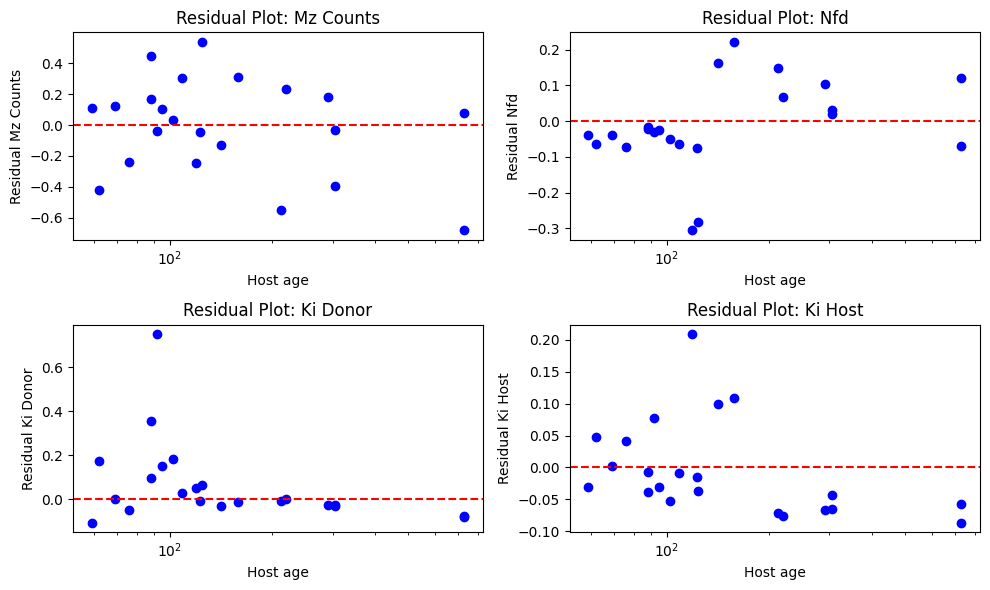

In [ ]:


fig, axes = plt.subplots(2, 2, figsize=(10, 6))

# Plot Residual Ki Donor
axes[1, 0].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Kid, axis=0), marker='o', color='b')
axes[1, 0].axhline(y=0, color='r', linestyle='--')
axes[1, 0].set_xlabel('Host age')
axes[1, 0].set_xscale('log')
axes[1, 0].set_ylabel('Residual Ki Donor')
axes[1, 0].set_title('Residual Plot: Ki Donor')

# Plot Residual Ki Host
axes[1, 1].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Kih, axis=0), marker='o', color='b')
axes[1, 1].axhline(y=0, color='r', linestyle='--')
axes[1, 1].set_xlabel('Host age')
axes[1, 1].set_xscale('log')
axes[1, 1].set_ylabel('Residual Ki Host')
axes[1, 1].set_title('Residual Plot: Ki Host')

# Plot Residual Nfd
axes[0, 1].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Nfd, axis=0), marker='o', color='b')
axes[0, 1].axhline(y=0, color='r', linestyle='--')
axes[0, 1].set_xlabel('Host age')
axes[0,1].set_xscale('log')
axes[0, 1].set_ylabel('Residual Nfd')
axes[0, 1].set_title('Residual Plot: Nfd')

# Plot Residual Mz Counts
axes[0, 0].scatter(x=df['Age at S1K'], y=np.mean(data_neutral.residuals_Mz, axis=0), marker='o', color='b')
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_xlabel('Host age')
axes[0,0].set_xscale('log')
axes[0, 0].set_ylabel('Residual Mz Counts')
axes[0, 0].set_title('Residual Plot: Mz Counts')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
# Calculate elpdf for the model

idata = az.from_cmdstanpy(data_neutral, log_likelihood={"log_lik_Mz": "log_lik_Mz", "log_lik_Nfd": "log_lik_Nfd", "log_lik_Kid": "log_lik_Kid", "log_lik_Kih": "log_lik_Kih"})

# Compute Loo CV for models with several Likelihoods 
import xarray as xr

# Concatenate the log_likelihood arrays

a1 = np.array(idata.log_likelihood["log_lik_Mz"])
a2 = np.array(idata.log_likelihood["log_lik_Nfd"])
a3 = np.array(idata.log_likelihood["log_lik_Kid"])
a4 = np.array(idata.log_likelihood["log_lik_Kih"])

log_lik = np.concatenate((a1, a2, a3, a4), axis=2)

# Convert the concatenated array to an xarray DataArray
idata.log_likelihood["combined_log_lik"] = xr.DataArray(log_lik, dims=["chain", "draw", "log_likelihood_dim"], coords={"chain": np.arange(log_lik.shape[0]), "draw": np.arange(log_lik.shape[1]), "log_likelihood_dim": np.arange(log_lik.shape[2])})

# Compute loo_cv
loo = loo_result1_combined = az.loo(idata, var_name="combined_log_lik")
print(loo)

/home/apoorva/Desktop/work/MZ_analysis/.venv/lib/python3.10/site-packages/arviz/stats/diagnostics.py:655: RuntimeWarning: invalid value encountered in scalar subtract
  if (np.max(ary) - np.min(ary)) < np.finfo(float).resolution:  # pylint: disable=no-member
/home/apoorva/Desktop/work/MZ_analysis/.venv/lib/python3.10/site-packages/arviz/stats/stats_utils.py:39: RuntimeWarning: invalid value encountered in subtract
  ary = ary - ary.mean(axis, keepdims=True)
/home/apoorva/Desktop/work/MZ_analysis/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:185: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)
/home/apoorva/Desktop/work/MZ_analysis/.venv/lib/python3.10/site-packages/arviz/stats/diagnostics.py:655: RuntimeWarning: invalid value encountered in scalar subtract
  if (np.max(ary) - np.min(ary)) < np.finfo(float).resolution:  # pylint: disable=no-member
/home/apoorva/Desktop/work/MZ_analysis/.venv/lib/python3.10/site-packages/arviz/stats/stat

Computed from 8000 posterior samples and 88 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    28.92    13.40
p_loo       12.49        -

There has been a warning during the calculation. Please check the results.
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       86   97.7%
   (0.70, 1]   (bad)         1    1.1%
   (1, Inf)   (very bad)    1    1.1%



/home/apoorva/Desktop/work/MZ_analysis/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/apoorva/Desktop/work/MZ_analysis/.venv/lib/python3.10/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/apoorva/Desktop/work/MZ_analysis/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Mean and standard deviation of the parameters:
rho: 0.023267630562500002 0.0027055635470197674
phi: 0.001284057545375 0.00020657678528922713
kappa_0: 0.16252914446757502 0.10929490042971461
y0: 2490113.03875 188590.59988120696
MZ_COUNT 2490113.03875 188590.59988120696


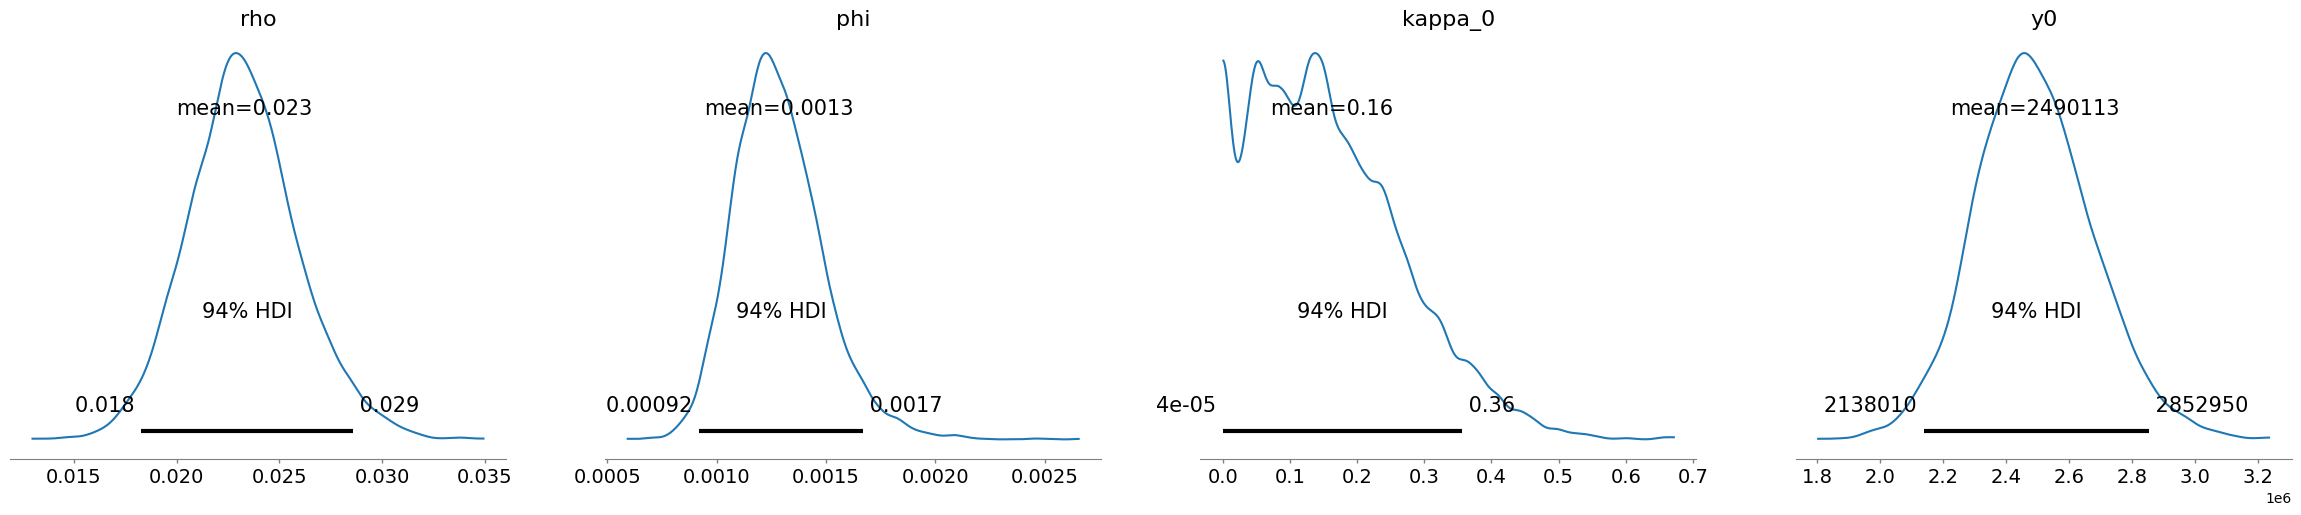

In [ ]:
#Plot the posterior distribution of the parameters
# az.plot_posterior(data_neutral, var_names=['rho', 'delta','kappa_0', 'y0', 'lamda'], kind='kde')
az.plot_posterior(data_neutral, var_names=['rho', 'phi','kappa_0', 'y0'], kind='kde')
# az.plot_posterior(data_neutral, var_names=['rho', 'phi', 'r_d', 37'kappa_0', 'y0'], kind='kde')



# Print mean and standard deviation of the parameters
print("Mean and standard deviation of the parameters:")
print("rho:", np.mean(data_neutral.rho), np.std(data_neutral.rho))
print("phi:", np.mean(data_neutral.phi), np.std(data_neutral.phi))
# print("delta:", np.mean(data_neutral.delta), np.std(data_neutral.delta))
# print("lamda:", np.mean(data_neutral.lamda), np.std(data_neutral.lamda))
print("kappa_0:", np.mean(data_neutral.kappa_0), np.std(data_neutral.kappa_0))
print("y0:", np.mean(data_neutral.y0), np.std(data_neutral.y0))
print('MZ_COUNT', np.mean(data_neutral.MZ_counts_mean), np.std(data_neutral.MZ_counts_mean))


Daily Influx: 23913.85061098506 3401.1537756420753


/tmp/ipykernel_1784704/3107610887.py:63: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


<Figure size 800x600 with 0 Axes>

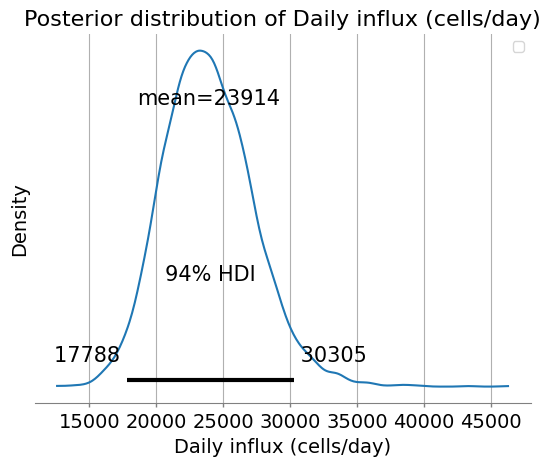

In [ ]:
#Plot error bars for daily influx across all models 
phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')

phi_samples_T2 = data_neutral_T2.stan_variable('phi')
rho_samples_T2 = data_neutral_T2.stan_variable('rho')
M_stable_samples_T2 = data_neutral_T2.stan_variable('MZ_counts_pred1')

phi_samples_FO = data_neutral_FO.stan_variable('phi')
rho_samples_FO = data_neutral_FO.stan_variable('rho')
M_stable_samples_FO = data_neutral_FO.stan_variable('MZ_counts_pred1')

phi_samples_T2MZP = data_neutral_T2MZP.stan_variable('phi')
rho_samples_T2MZP = data_neutral_T2MZP.stan_variable('rho')
M_stable_samples_T2MZP = data_neutral_T2MZP.stan_variable('MZ_counts_pred1')

ts= np.arange(59, 731, 1)

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

delta_T1 = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
delta_T2 = ((phi_samples_T2 * 1308516) / M_stable_samples_T2[:,0] ) + rho_samples_T2
delta_FO = ((phi_samples_FO * np.mean(theta_spline(ts))) / M_stable_samples_FO[:,0] ) + rho_samples_FO
delta_T2MZP = ((phi_samples_T2MZP * 1788129) / M_stable_samples_T2MZP[:,0] ) + rho_samples_T2MZP


P_T1= phi_samples * 1298783
P_T2 = phi_samples_T2 * 1308516
P_FO = phi_samples_FO * np.mean(theta_spline(ts))
P_T2MZP = phi_samples_T2MZP * 1788129


# # Interdivision time
interdivision_time_T1 = 1 / rho_samples
interdivision_time_T2 = 1 / rho_samples_T2
interdivision_time_FO = 1 / rho_samples_FO
interdivision_time_T2MZP = 1 / rho_samples_T2MZP

# Residence time
residence_time_T1 = 1 / delta_T1
residence_time_T2 = 1 / delta_T2
residence_time_FO = 1 / delta_FO
residence_time_T2MZP = 1 / delta_T2MZP

#Plot P_T2 posterior 
plt.figure(figsize=(8, 6))

# sns.kdeplot(P_T2, label='T2', fill=True, color='orange', alpha=0.5)

az.plot_posterior(P_T2, kind='kde')
print("Daily Influx:", np.mean(P_T2), np.std(P_T2))
# plt.axvline(np.mean(P_T2), color='orange', linestyle='dashed', linewidth=1)

plt.xlabel('Daily influx (cells/day)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.title('Posterior distribution of Daily influx (cells/day)', fontsize=16)
plt.legend()
plt.grid()

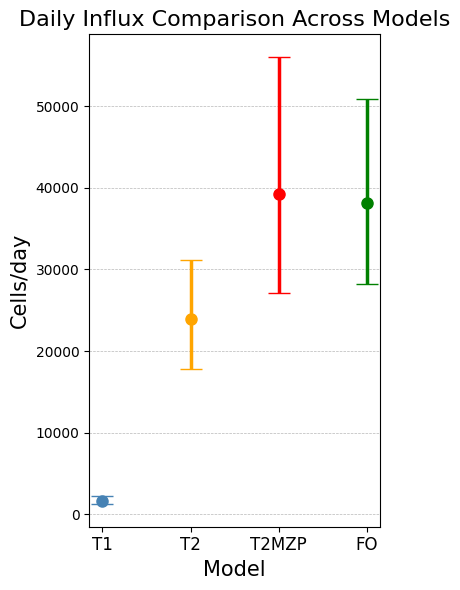

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'red', 'green']
models = [P_T1, P_T2, P_T2MZP, P_FO]
labels = ['T1', 'T2', 'T2MZP', 'FO']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Cells/day', fontsize=15)
ax.set_xlabel('Model', fontsize=15)
ax.set_title('Daily Influx Comparison Across Models', fontsize=16)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

plt.tight_layout()
plt.show()

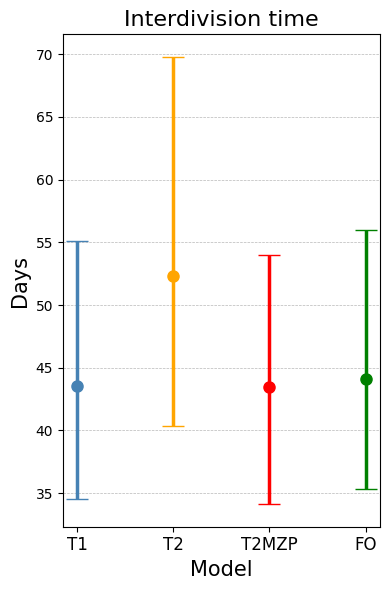

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'red', 'green']
models = [interdivision_time_T1, interdivision_time_T2, interdivision_time_T2MZP, interdivision_time_FO]
labels = ['T1', 'T2', 'T2MZP', 'FO']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Days', fontsize=15)
ax.set_xlabel('Model', fontsize=15)
ax.set_title('Interdivision time', fontsize=16)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

plt.tight_layout()
plt.show()

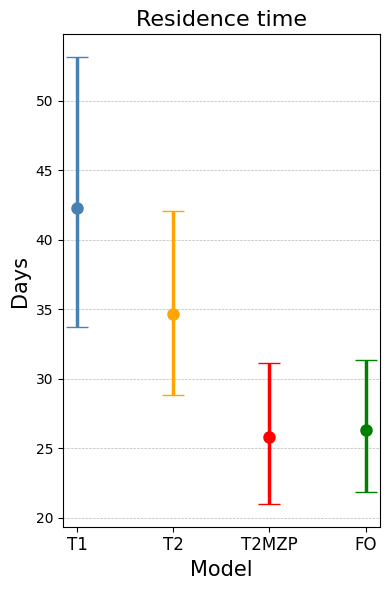

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(4, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'red', 'green']
models = [residence_time_T1, residence_time_T2, residence_time_T2MZP, residence_time_FO]
labels = ['T1', 'T2', 'T2MZP', 'FO']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Days', fontsize=15)
ax.set_xlabel('Model', fontsize=15)
ax.set_title('Residence time', fontsize=16)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

plt.tight_layout()
plt.show()

28440715.823468454


/tmp/ipykernel_1784704/2236633669.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels([12000,  18000, 24000, 30000], fontsize=15)


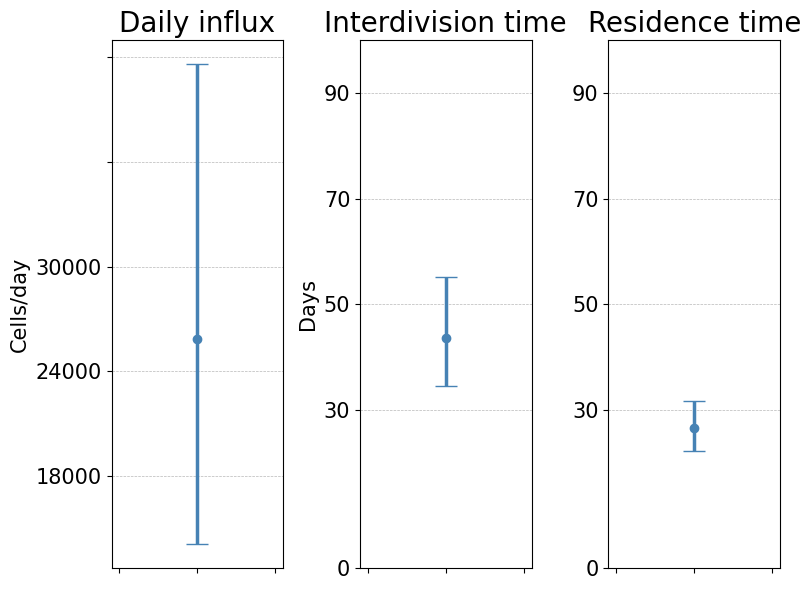

In [ ]:
# Calculate clonal half-life for ontogeny predictions
from numpy import real

phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')
 
ts= np.arange(59, 731, 1)

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

# delta = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * 1308516) / M_stable_samples[:,0] ) + rho_samples
delta = ((phi_samples * np.mean(theta_spline(ts))) / M_stable_samples[:,0] ) + rho_samples


# P = phi_samples * 1298783
# P = phi_samples * 1308516
P = phi_samples * np.mean(theta_spline(ts))

print(np.mean(theta_spline
              (ts)))
# Interdivision time
interdivision_time = 1 / rho_samples

# Residence time
residence_time = 1 / delta

# Plot error plot for interdivision, clonal half-life , residence time

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)


# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))

# Plot rho_inv
plot_with_error_bars(interdivision_time, 'rho_inv', 'steelblue', axes[1])


# Plot lamda_inv
# plot_with_error_bars(data_neutral.lamda_inv, 'lamda_inv', 'steelblue', axes[0])
plot_with_error_bars(P, 'Daily Influx', 'steelblue', axes[0])
axes[0].set_ylabel('Cells/day', fontsize=15)
# axes[0].set_ylim(10000, 35000)
# axes[0].set_yticks([12000,  18000, 24000, 30000])
# axes[0].set_yticks([12000,  18000, 24000])
axes[0].set_yticklabels([12000,  18000, 24000, 30000], fontsize=15)
# axes[0].set_yticklabels([12000,  18000, 24000], fontsize=15)

axes[0].set_xticklabels([])
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)


# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('Interdivision time', fontsize=20)
axes[1].set_ylabel('Days', fontsize=15)
axes[1].set_ylim(0, 100)
axes[1].set_yticks([0, 30, 50, 70, 90])
axes[1].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[1].set_xticklabels([])
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
axes[0].set_title('Daily influx', fontsize=20)
axes[2].set_title('Residence time', fontsize=20)
axes[2].set_ylim(0, 100)
axes[2].set_yticks([0, 30, 50, 70, 90])
axes[2].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[2].set_xticklabels([])
axes[2].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Plot delta_inv
plot_with_error_bars(residence_time, 'delta_inv', 'steelblue', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()

#save the figure
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/ontogeny_clonalhalf_life.png', dpi=350, bbox_inches='tight')

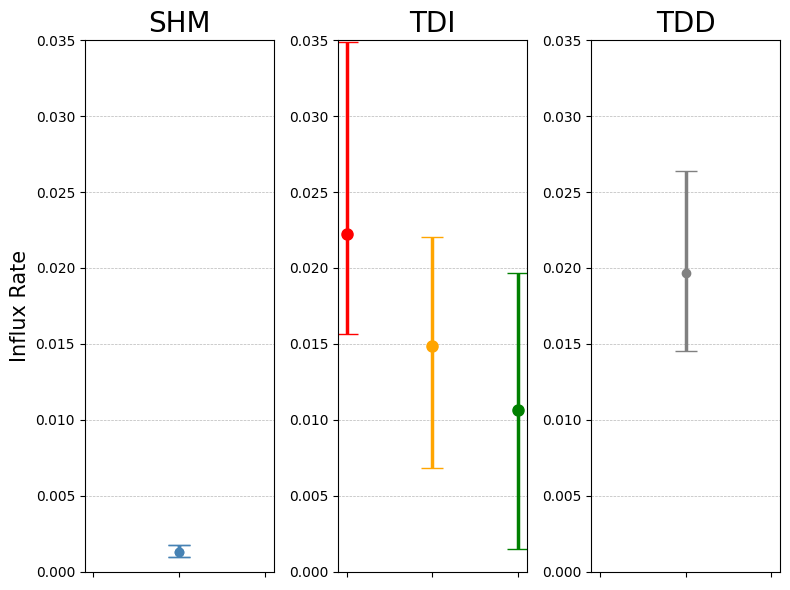

In [ ]:
# Error plot for phi, division, delta between SHM, TDI, TDD

phi_shm = data_neutral.stan_variable('phi')
rho_shm = data_neutral.stan_variable('rho')
M_stable_shm = data_neutral.stan_variable('MZ_counts_pred1')

phi_tdi = data_neutral_TDI.stan_variable('phi')
rho_tdi = data_neutral_TDI.stan_variable('rho')
r_d_tdi = data_neutral_TDI.stan_variable('r_d')
M_stable_tdi = data_neutral_TDI.stan_variable('MZ_counts_pred1')

phi_tdd = data_neutral_TDD.stan_variable('phi')
rho_tdd = data_neutral_TDD.stan_variable('rho')
r_d_tdd = data_neutral_TDD.stan_variable('r_d')
M_stable_tdd = data_neutral_TDD.stan_variable('MZ_counts_pred1')

ts= np.arange(40, 731, 1)
def phi_func(t, phi, r_d):
    return  phi * np.exp(-r_d * (t - 40)) # Adjusted to start decay after t=40

# Calculate phi function values at t=40, 365, 731 for TDI
time_points = [40, 365, 731]
phi_values_tdi = []
for t in time_points:
    phi_t = phi_func(t, phi_tdi, r_d_tdi)
    phi_values_tdi.append(phi_t)
phi_values_tdi = np.array(phi_values_tdi).T  # Shape: (n_samples, 3)


# Plot error plot for interdivision, clonal half-life , residence time

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)

def plot_with_error_bars_timepoints(data, labels, colors, ax):
    for i, (label, color) in enumerate(zip(labels, colors)):
        mean_data = np.mean(data[:, i])
        lower_ci = np.quantile(data[:, i], 0.025)
        upper_ci = np.quantile(data[:, i], 0.975)
        
        ax.errorbar(i, mean_data, yerr=[[mean_data - lower_ci], [upper_ci - mean_data]], 
                    fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                    label=f'{label} days')

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))


plot_with_error_bars(phi_shm, 'SHM', 'steelblue', axes[0])
# plot_with_error_bars(phi_tdi, 'TDI', 'orange', axes[1])
plot_with_error_bars_timepoints(phi_values_tdi, 
                     ['40', '365', '731'], 
                     ['red', 'orange', 'green'], 
                     axes[1])

# ax.set_ylabel('φ(t) - Influx Rate', fontsize=15)
plot_with_error_bars(phi_tdd, 'TDD', 'grey', axes[2])

# Plot lamda_inv
# plot_with_error_bars(data_neutral.lamda_inv, 'lamda_inv', 'steelblue', axes[0])
plot_with_error_bars(phi_shm, 'SHM', 'steelblue', axes[0])
axes[0].set_ylabel('Influx Rate', fontsize=15)
axes[0].set_ylim(0, 0.035)
# axes[0].set_yticks([12000, 15000, 18000, 21000, 24000])
# axes[0].set_yticklabels([12000, 15000, 18000, 21000, 24000], fontsize=15)
axes[0].set_title('SHM', fontsize=20)
axes[0].set_xticklabels([])
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)


# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('TDI', fontsize=20)
# axes[1].set_ylabel('Days', fontsize=15)
axes[1].set_ylim(0, 0.035)
# axes[1].set_yticks([0, 30, 50, 70, 90])
# axes[1].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[1].set_xticklabels([])
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

axes[2].set_title('TDD', fontsize=20)
axes[2].set_ylim(0, 0.035)
# axes[2].set_yticks([0, 30, 50, 70, 90])
# axes[2].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[2].set_xticklabels([])
axes[2].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Plot delta_inv
# plot_with_error_bars(residence_time, 'delta_inv', 'steelblue', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()

#save the figure
# plt.savefig('/home/apoorva/Desktop/work/MZ_analysis/figures/ontogeny_clonalhalf_life.png', dpi=350, bbox_inches='tight')

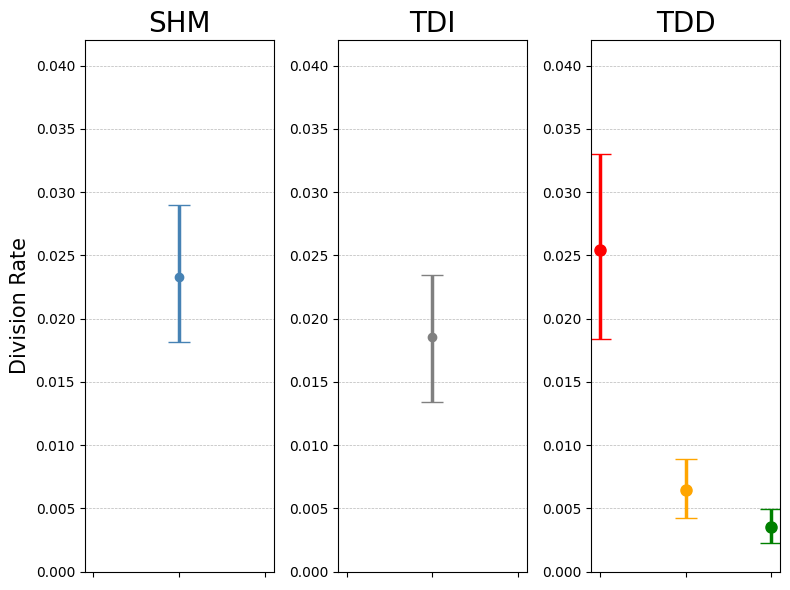

In [ ]:
# Error plot for division between SHM, TDI, TDD
def rho_func(t, rho, r_d):
    # return rho * np.exp(-r_d * (t-40)) # Adjusted to start decay after t=40
    return rho/ (1 + (t/r_d))

# Calculate rho function values at t=40, 365, 731 for TDI
time_points = [40, 365, 731]
rho_values_tdd = []
for t in time_points:
    rho_t = rho_func(t, rho_tdd, r_d_tdd)
    rho_values_tdd.append(rho_t)
rho_values_tdd = np.array(rho_values_tdd).T  # Shape: (n_samples, 3)


def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)

def plot_with_error_bars_timepoints(data, labels, colors, ax):
    for i, (label, color) in enumerate(zip(labels, colors)):
        mean_data = np.mean(data[:, i])
        lower_ci = np.quantile(data[:, i], 0.025)
        upper_ci = np.quantile(data[:, i], 0.975)
        
        ax.errorbar(i, mean_data, yerr=[[mean_data - lower_ci], [upper_ci - mean_data]], 
                    fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                    label=f'{label} days')

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))


plot_with_error_bars(rho_shm, 'SHM', 'steelblue', axes[0])
# plot_with_error_bars(rho_tdi, 'TDI', 'orange', axes[1])
plot_with_error_bars_timepoints(rho_values_tdd, 
                     ['40', '365', '731'], 
                     ['red', 'orange', 'green'], 
                     axes[2])

# ax.set_ylabel('φ(t) - Influx Rate', fontsize=15)
plot_with_error_bars(rho_tdi, 'TDI', 'grey', axes[1])


axes[0].set_ylabel('Division Rate', fontsize=15)
axes[0].set_ylim(0, 0.042)
# axes[0].set_yticks([12000, 15000, 18000, 21000, 24000])
# axes[0].set_yticklabels([12000, 15000, 18000, 21000, 24000], fontsize=15)
axes[0].set_title('SHM', fontsize=20)
axes[0].set_xticklabels([])
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)


# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('TDI', fontsize=20)
# axes[1].set_ylabel('Days', fontsize=15)
axes[1].set_ylim(0, 0.042)
# axes[1].set_yticks([0, 30, 50, 70, 90])
# axes[1].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[1].set_xticklabels([])
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

axes[2].set_title('TDD', fontsize=20)
axes[2].set_ylim(0, 0.042)
# axes[2].set_yticks([0, 30, 50, 70, 90])
# axes[2].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[2].set_xticklabels([])
axes[2].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Plot delta_inv
# plot_with_error_bars(residence_time, 'delta_inv', 'steelblue', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()

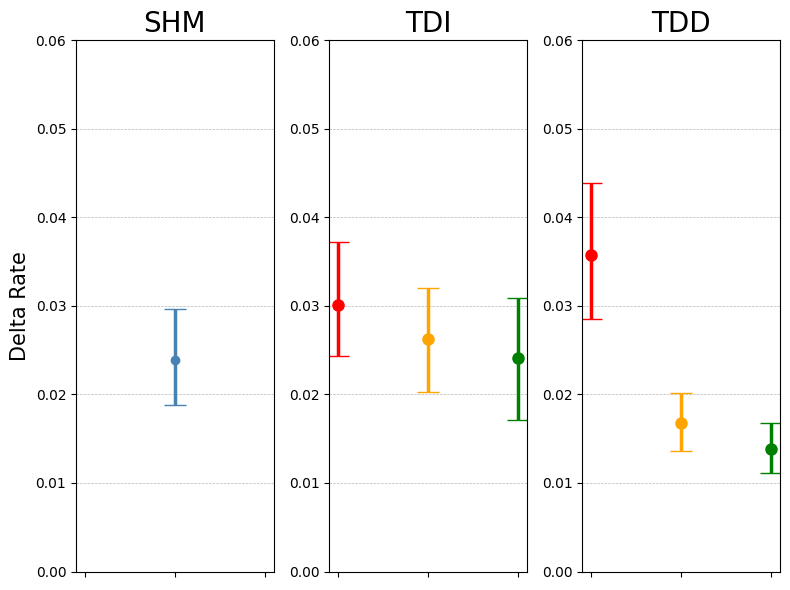

In [ ]:
# Compute delta
delta_shm = ((phi_shm * 1298783) / M_stable_shm[:,0] ) + rho_shm
# delta_shm = ((phi_shm * 1298783) / M_stable_shm[:,0] ) + rho_shm
# delta_shm = ((phi_shm * 1298783) / M_stable_shm[:,0] ) + rho_shm


# Calculate rho function values at t=40, 365, 731 for TDI
time_points = [40, 365, 731]
delta_values_tdi = []
delta_values_tdd = []
for t in time_points:
    delta_ti = ((phi_func(t, phi_tdi, r_d_tdi) * 1298783) / M_stable_tdi[:,0]) + rho_tdi
    delta_t = ((phi_tdd * 1298783) / M_stable_tdd[:,0]) + rho_func(t, rho_tdd, r_d_tdd)
    delta_values_tdd.append(delta_t)
    delta_values_tdi.append(delta_ti)
delta_values_tdd = np.array(delta_values_tdd).T  # Shape: (n_samples, 3)
delta_values_tdi = np.array(delta_values_tdi).T  # Shape: (n_samples, 3)

def plot_with_error_bars(data, label, color, ax):
    mean_data = np.mean(data, axis=0)
    lower_ci = np.quantile(data, 0.025, axis=0)
    upper_ci = np.quantile(data, 0.975, axis=0)
    
    # Ensure mean_rho_inv, lower_ci, and upper_ci are arrays
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    x_values = np.arange(len(mean_data))
    
    ax.errorbar(x_values, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color= color, capsize=8, markersize=6, elinewidth=2.5)
    # ax.set_xlabel('Index', fontsize=12)
    # ax.set_ylabel(label, fontsize=12)

def plot_with_error_bars_timepoints(data, labels, colors, ax):
    for i, (label, color) in enumerate(zip(labels, colors)):
        mean_data = np.mean(data[:, i])
        lower_ci = np.quantile(data[:, i], 0.025)
        upper_ci = np.quantile(data[:, i], 0.975)
        
        ax.errorbar(i, mean_data, yerr=[[mean_data - lower_ci], [upper_ci - mean_data]], 
                    fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                    label=f'{label} days')

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(8, 6))


plot_with_error_bars(delta_shm, 'SHM', 'steelblue', axes[0])
# plot_with_error_bars(rho_tdi, 'TDI', 'orange', axes[1])
plot_with_error_bars_timepoints(delta_values_tdd, 
                     ['40', '365', '731'], 
                     ['red', 'orange', 'green'], 
                     axes[2])

# ax.set_ylabel('φ(t) - Influx Rate', fontsize=15)
plot_with_error_bars_timepoints(delta_values_tdi, 
                     ['40', '365', '731'], 
                     ['red', 'orange', 'green'], 
                     axes[1])


axes[0].set_ylabel('Delta Rate', fontsize=15)
axes[0].set_ylim(0, 0.06)
# axes[0].set_yticks([12000, 15000, 18000, 21000, 24000])
# axes[0].set_yticklabels([12000, 15000, 18000, 21000, 24000], fontsize=15)
axes[0].set_title('SHM', fontsize=20)
axes[0].set_xticklabels([])
axes[0].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)


# axes[0].set_xlabel('Index', fontsize=8)
# axes[0].legend(['Chimera', 'Young+Chimera'], fontsize=6)
axes[1].set_title('TDI', fontsize=20)
# axes[1].set_ylabel('Days', fontsize=15)
axes[1].set_ylim(0, 0.06)
# axes[1].set_yticks([0, 30, 50, 70, 90])
# axes[1].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[1].set_xticklabels([])
axes[1].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

axes[2].set_title('TDD', fontsize=20)
axes[2].set_ylim(0, 0.06)
# axes[2].set_yticks([0, 30, 50, 70, 90])
# axes[2].set_yticklabels([0, 30, 50, 70, 90], fontsize=15)
axes[2].set_xticklabels([])
axes[2].yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)

# Plot delta_inv
# plot_with_error_bars(residence_time, 'delta_inv', 'steelblue', axes[2])

# Adjust layout
plt.tight_layout()
plt.show()

Death: 0.023942388996179474 0.0027122979840946432


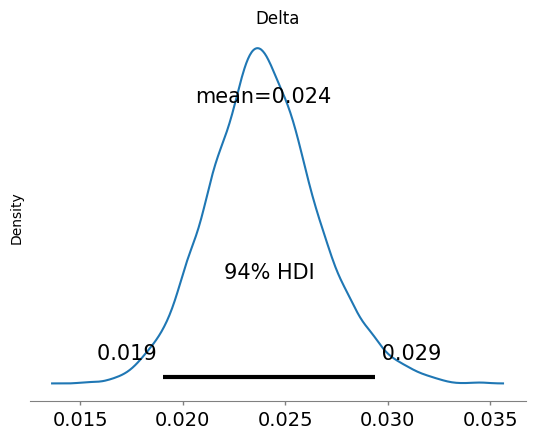

In [ ]:
# Get posterior samples for delta
phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

ts= np.arange(59, 731, 1)
delta = ((phi_samples * 1308516) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * np.mean(theta_spline(ts))) / M_stable_samples[:,0] ) + rho_samples


# P = phi * 1298783
az.plot_posterior(delta, kind='kde')
print("Death:", np.mean(delta), np.std(delta))


# # Plot the posterior distribution for alpha
# az.plot_posterior(phi, kind='kde')

# # Remove X from the plot

plt.ylabel('Density')
plt.title('Delta')
plt.show()

# print("phi:", np.mean(phi), np.std(phi))

Mean and SD for net loss: 0.0006747584336794725 9.545439415247926e-05


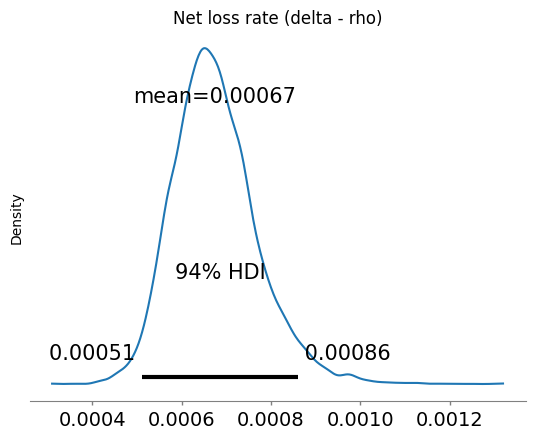

In [ ]:
# Get posterior samples for 'lambda' 
phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

ts= np.arange(59, 731, 1)

delta = ((phi_samples * 1308516) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
# delta = ((phi_samples * np.mean(theta_spline(ts))) / M_stable_samples[:,0] ) + rho_samples



net_loss = delta - rho_samples

# P = phi * 1298783
az.plot_posterior(net_loss, kind='kde')
print("Mean and SD for net loss:", np.mean(net_loss), np.std(net_loss))


# # Plot the posterior distribution for alpha
# az.plot_posterior(phi, kind='kde')

# # Remove X from the plot

plt.ylabel('Density')
plt.title('Net loss rate (delta - rho)')
plt.show()

In [ ]:
#Plot error bars for daily influx across all models 
phi_samples = data_neutral.stan_variable('phi')
rho_samples = data_neutral.stan_variable('rho')
M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')

phi_samples_T2 = data_neutral_T2.stan_variable('phi')
rho_samples_T2 = data_neutral_T2.stan_variable('rho')
M_stable_samples_T2 = data_neutral_T2.stan_variable('MZ_counts_pred1')

phi_samples_FO = data_neutral_FO.stan_variable('phi')
rho_samples_FO = data_neutral_FO.stan_variable('rho')
M_stable_samples_FO = data_neutral_FO.stan_variable('MZ_counts_pred1')

phi_samples_T2MZP = data_neutral_T2MZP.stan_variable('phi')
rho_samples_T2MZP = data_neutral_T2MZP.stan_variable('rho')
M_stable_samples_T2MZP = data_neutral_T2MZP.stan_variable('MZ_counts_pred1')

ts= np.arange(59, 731, 1)

def theta_spline(time):
  theta_est = 17
  nu = 0.00045
  t0 = 40  # t0 is the minimum mouse age
  theta_s = np.exp(theta_est) * np.exp(nu * (time - t0))
  return theta_s

delta_T1 = ((phi_samples * 1298783) / M_stable_samples[:,0] ) + rho_samples
delta_T2 = ((phi_samples_T2 * 1308516) / M_stable_samples_T2[:,0] ) + rho_samples_T2
delta_FO = ((phi_samples_FO * np.mean(theta_spline(ts))) / M_stable_samples_FO[:,0] ) + rho_samples_FO
delta_T2MZP = ((phi_samples_T2MZP * 1788129) / M_stable_samples_T2MZP[:,0] ) + rho_samples_T2MZP


P_T1= phi_samples * 1298783
P_T2 = phi_samples_T2 * 1308516
P_FO = phi_samples_FO * np.mean(theta_spline(ts))
P_T2MZP = phi_samples_T2MZP * 1788129


# # Interdivision time
interdivision_time_T1 = 1 / rho_samples
interdivision_time_T2 = 1 / rho_samples_T2
interdivision_time_FO = 1 / rho_samples_FO
interdivision_time_T2MZP = 1 / rho_samples_T2MZP

# Residence time
residence_time_T1 = 1 / delta_T1
residence_time_T2 = 1 / delta_T2
residence_time_FO = 1 / delta_FO
residence_time_T2MZP = 1 / delta_T2MZP


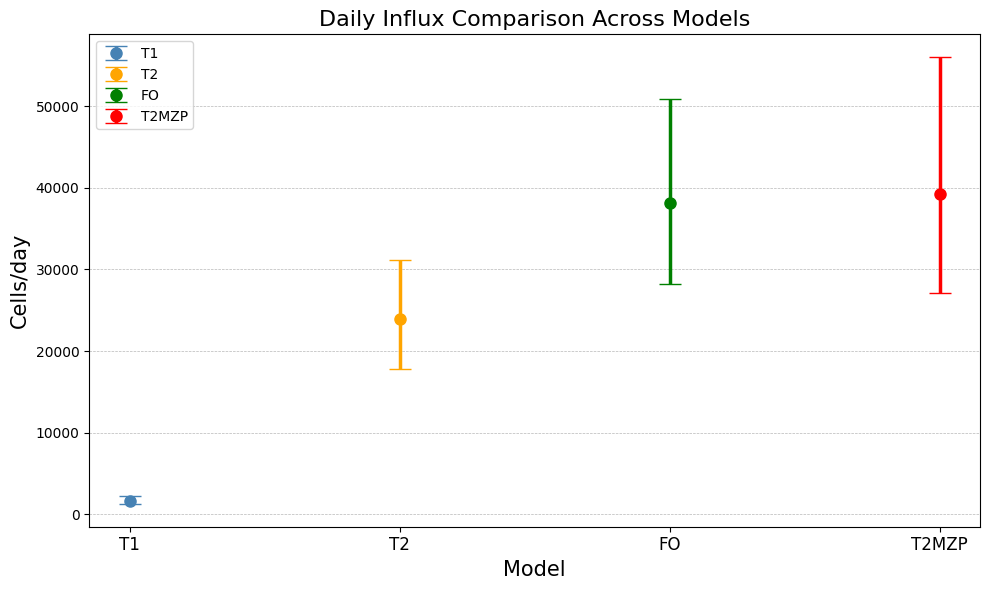

In [ ]:
# Create single subplot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

# Plot daily influx for each model with different colors
colors = ['steelblue', 'orange', 'green', 'red']
models = [P_T1, P_T2, P_FO, P_T2MZP]
labels = ['T1', 'T2', 'FO', 'T2MZP']

for i, (model_data, color, label) in enumerate(zip(models, colors, labels)):
    mean_data = np.mean(model_data, axis=0)
    lower_ci = np.quantile(model_data, 0.025, axis=0)
    upper_ci = np.quantile(model_data, 0.975, axis=0)
    
    mean_data = np.atleast_1d(mean_data)
    lower_ci = np.atleast_1d(lower_ci)
    upper_ci = np.atleast_1d(upper_ci)
    
    ax.errorbar(i, mean_data, yerr=[mean_data - lower_ci, upper_ci - mean_data], 
                fmt='o', color=color, capsize=8, markersize=8, elinewidth=2.5, 
                label=label)

ax.set_ylabel('Cells/day', fontsize=15)
ax.set_xlabel('Model', fontsize=15)
ax.set_title('Daily Influx Comparison Across Models', fontsize=16)
ax.set_xticks(range(4))
ax.set_xticklabels(labels, fontsize=12)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, alpha=0.9)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
#Plot rho function 
ts= np.arange(40, 731, 1)
def phi_func(t, phi, r_d):
    return  phi / (1 +  np.exp(-r_d * (t - 40))) # Adjusted to start decay after t=40
plt.figure(figsize=(10, 6))
plt.plot(ts, phi_func(ts, np.mean(data_neutral.phi), np.mean(data_neutral.r_d)), alpha=0.7, color='Steelblue', label='Mean phi(t)')
# Add uncertainty bands
plt.fill_between(ts, phi_func(ts, np.quantile(data_neutral.phi, 0.025, axis=0), np.quantile(data_neutral.r_d, 0.025, axis=0)), 
                 phi_func(ts, np.quantile(data_neutral.phi, 0.975, axis=0), np.quantile(data_neutral.r_d, 0.975, axis=0)), 
                 alpha=0.2, color='steelblue', label='95% CI')
plt.xlabel('Host age (days)', fontsize=14)
plt.ylabel('phi(t)', fontsize=14)
plt.title('Change in phi over time', fontsize=16)
# plt.yscale('log')
plt.xscale('log')
plt.xlim(40, 731)
plt.ylim(0, 0.04)
plt.xticks([40, 100, 300, 600], [40, 100, 300, 600])
plt.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.show()

AttributeError: Unknown variable name: r_d
Available variables are y0_Log, kappa_0, sigma, rho, phi, k_hat, totalMz_mean, Nfd_mean, Kid_mean, Kih_mean, MZ_counts_mean, donor_fractions_mean, host_ki_mean, donor_ki_mean, parms, initial_cond, y0, k_hat_pred1, k_hat_pred2, MZ_counts_pred1, Nfd_pred1, host_ki_pred1, donor_ki_pred1, MZ_counts_pred2, Nfd_pred2, host_ki_pred2, donor_ki_pred2, MZ_counts_pred1_err, Nfd_pred1_err, host_ki_pred1_err, donor_ki_pred1_err, MZ_counts_pred2_err, Nfd_pred2_err, host_ki_pred2_err, donor_ki_pred2_err, rho_inv, log_lik_Mz, log_lik_Nfd, log_lik_Kid, log_lik_Kih, residuals_Mz, residuals_Nfd, residuals_Kid, residuals_Kih

<Figure size 1000x600 with 0 Axes>

In [ ]:
# # Get posterior samples for 'lambda' and 'M_stable'
# phi_samples = data_neutral.stan_variable('phi')
# rho_samples = data_neutral.stan_variable('rho')
# M_stable_samples = data_neutral.stan_variable('MZ_counts_pred1')



# delta = (phi_samples * 1308516) / M_stable_samples[:,0]+ rho_samples

# # Plot the posterior distribution for alpha
# az.plot_posterior(delta, kind='kde')

# # Remove X from the plot

# plt.ylabel('Density')
# plt.title('delta = phi P/ M_stable + rho')
# plt.show()

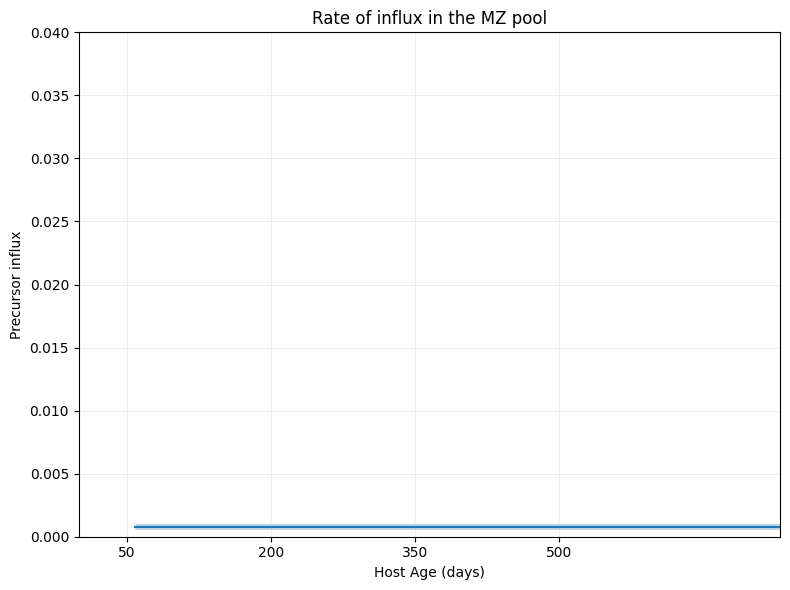

In [ ]:
delta= np.zeros((data_neutral.rho.shape[0], len(data_neutral.MZ_counts_pred1[0])))
death = (data_neutral.phi * 1308516 ) /  data_neutral.MZ_counts_pred1[:,0] # influx rate calculated from the loss and division rate
for i in range(data_neutral.MZ_counts_pred1.shape[1]):
	delta[:, i] = death
 
fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(delta, axis=0))
axes.fill_between(ts1, np.quantile(delta, 0.025, axis=0), np.quantile(delta, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.04)
axes.set_xlim(0, 730)
axes.set_xticks([50, 200, 350, 500])
axes.set_xticklabels([50, 200, 350, 500])
axes.set_ylabel('Precursor influx')
axes.set_xlabel('Host Age (days)')
# axes.set_title('Ratio of influx produced by precursor cells to self-renewing cells in the MZ pool') 
axes.set_title('Rate of influx in the MZ pool')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

# mean_delta = np.mean(delta, axis=0)
# print('Mean death rate at different ages:', mean_delta)

In [ ]:
# Define 2D array for influx of shape (10000, 708)

influx = np.zeros((data_neutral.rho.shape[0], len(data_neutral.MZ_counts_pred1[0])))
phi = (data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0]) / 1308516  # influx rate calculated from the loss and division rate
for i in range(data_neutral.MZ_counts_pred1.shape[1]):
	influx[:, i] = phi 
 

# CI for precursor 

# influx = []
# for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
# 	influx.append((data_neutral.phi * 1118208) / (data_neutral.rho * data_neutral.MZ_counts_pred1[:, i]))

# influx = np.array(influx)
# print(len(influx))
# print(influx.shape)
# print(np.quantile(influx, 0.025, axis=0))
# print(np.quantile(influx, 0.975, axis=0))

# Plot precursor influx with 95% CI

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(influx, axis=0))
axes.fill_between(ts1, np.quantile(influx, 0.025, axis=0), np.quantile(influx, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.04)
axes.set_xlim(0, 730)
axes.set_xticks([50, 200, 350, 500])
axes.set_xticklabels([50, 200, 350, 500])
axes.set_ylabel('Precursor influx')
axes.set_xlabel('Host Age (days)')
# axes.set_title('Ratio of influx produced by precursor cells to self-renewing cells in the MZ pool') 
axes.set_title('Rate of influx in the MZ pool')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
plt.tight_layout()
plt.show()

print(phi.shape)
print(np.mean(phi, axis=0))
print(np.std(phi, axis=0))




AttributeError: Unknown variable name: lamda
Available variables are y0_Log, kappa_0, sigma, phi, rho, r_d, k_hat, totalMz_mean, Nfd_mean, Kid_mean, Kih_mean, MZ_counts_mean, donor_fractions_mean, host_ki_mean, donor_ki_mean, parms, initial_cond, y0, k_hat_pred1, k_hat_pred2, k_hat_pred3, MZ_counts_pred1, Nfd_pred1, host_ki_pred1, donor_ki_pred1, MZ_counts_pred2, Nfd_pred2, host_ki_pred2, donor_ki_pred2, MZ_counts_pred3, Nfd_pred3, host_ki_pred3, donor_ki_pred3, rho_rate, log_lik_Mz, log_lik_Nfd, log_lik_Kid, log_lik_Kih, residuals_Mz, residuals_Nfd, residuals_Kid, residuals_Kih

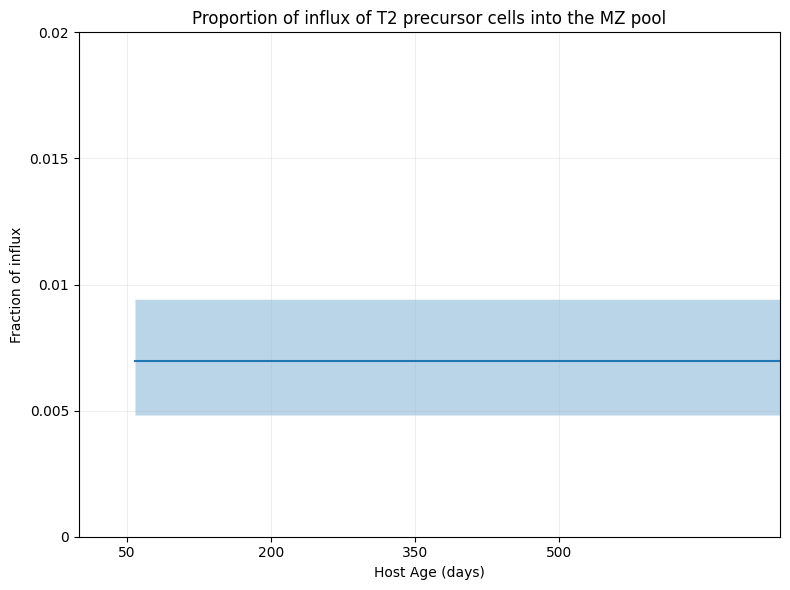

In [ ]:
influx_p = np.zeros((data_neutral.rho.shape[0], len(data_neutral.MZ_counts_pred1[0])))
for i in range(0, len(data_neutral.MZ_counts_pred1[0])):
	influx_p[:, i] = (data_neutral.lamda)
 

# # influx = np.array(influx)
# print(np.quantile(influx_p, 0.025, axis=0))
# print(np.quantile(influx_p, 0.975, axis=0))

# Plot precursor influx with 95% CI

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
axes.plot(ts1, np.mean(influx_p, axis=0))
axes.fill_between(ts1, np.quantile(influx_p, 0.025, axis=0), np.quantile(influx_p, 0.975, axis=0), alpha=0.3)
axes.set_ylim(0, 0.02)
axes.set_yticks([0, 0.005, 0.01, 0.015, 0.02])
axes.set_yticklabels([0, 0.005, 0.01, 0.015, 0.02])
axes.set_xlim(0, 730)
axes.set_xticks([50, 200, 350, 500])
axes.set_xticklabels([50, 200, 350, 500])
axes.set_ylabel('Fraction of influx')
axes.set_xlabel('Host Age (days)')
axes.grid(True, which='both', ls="solid", linewidth=0.5, alpha=0.3)
axes.set_title('Proportion of influx of T2 precursor cells into the MZ pool')
plt.tight_layout()
plt.show()


In [ ]:
print(np.mean(data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0]))
print(np.std(data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0]))

#Credible intervals for precursor influx
print(np.quantile(data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0], 0.025))
print(np.quantile(data_neutral.lamda * data_neutral.MZ_counts_pred1[:,0], 0.975))

17244.71781438148
3164.8454028165224
11533.203693180001
23935.034080265


In [ ]:
# Mean and standard deviation of the predicted net loss rate

print(np.mean(data_neutral.lamda))
print(np.std(data_neutral.lamda))

0.0069739848960000015
0.0011697557065091452


In [ ]:
# Mean and standard deviation of the predicted MZ counts

print(np.mean(data_neutral.MZ_counts_pred1))
print(np.std(data_neutral.MZ_counts_pred1))


2473136.01
188346.71935380212


In [ ]:
# print(np.mean(data_neutral.delta))

print(data_neutral.rho.shape)
print(len(data_neutral.MZ_counts_pred1[0]))
# print(data_neutral.rh o * data_neutral.MZ_counts_pred1)
# print(np.mean(data_neutral.lamda_inv))
# print(np.mean(data_neutral.beta_inv))
# print(np.mean(data_neutral.rho_inv))
# print(data_neutral.rho * data_neutral.MZ_counts_pred1[15])
# Mz_60 = data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15]
# print(np.mean(Mz_60))
# # print((data_neutral.MZ_counts_pred1[:, 15]))
# #calculate credible interval

# print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], 0.025))
# print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], 0.975))

# print('Credible interval for MZ cells at 60 days:', np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 15], [0.025, 0.975]))




(5000,)
691


In [ ]:
Mz_350 = data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305]
print(np.mean(Mz_350))
print((data_neutral.MZ_counts_pred1[:, 305]))


print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305], 0.025))
print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 305], 0.975))

39240.78019984952
[2566210. 2657230. 2239640. ... 2667060. 2461960. 2265380.]
29522.092847425
50334.370005074976


In [ ]:
Mz_600 = data_neutral.rho * data_neutral.MZ_counts_pred3[:, 555]
print(np.mean(Mz_600))
print((data_neutral.MZ_counts_pred1[:, 555]))


print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 555], 0.025))
print(np.quantile(data_neutral.rho * data_neutral.MZ_counts_pred1[:, 555], 0.975))

IndexError: index 555 is out of bounds for axis 1 with size 459